In [3]:
!pip install warp-lang

## warp working

Grid: 200×100
Scheme: MUSCL (GPU - cuda)
Time stepping: EULER
Estimated total steps: ~50
Module __main__ 6124ca4 load on device 'cuda:0' took 2552.63 ms  (compiled)
Step     20 | t=0.02014/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5473 | speed=7.8 steps/s
Step     40 | t=0.03792/0.2 | dt=0.00089 | ρ=0.5625 | p=0.5447 | speed=15.6 steps/s
Step     60 | t=0.05599/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5421 | speed=23.3 steps/s
Step     80 | t=0.07405/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5395 | speed=31.0 steps/s
Step    100 | t=0.09219/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5368 | speed=38.7 steps/s
Step    120 | t=0.11035/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5342 | speed=46.3 steps/s
Step    140 | t=0.12852/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5315 | speed=53.9 steps/s
Step    160 | t=0.14671/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5289 | speed=61.5 steps/s
Step    180 | t=0.16490/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5262 | speed=69.0 steps/s
Step    200 | t=0.18309/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5236 | speed=76.5 step

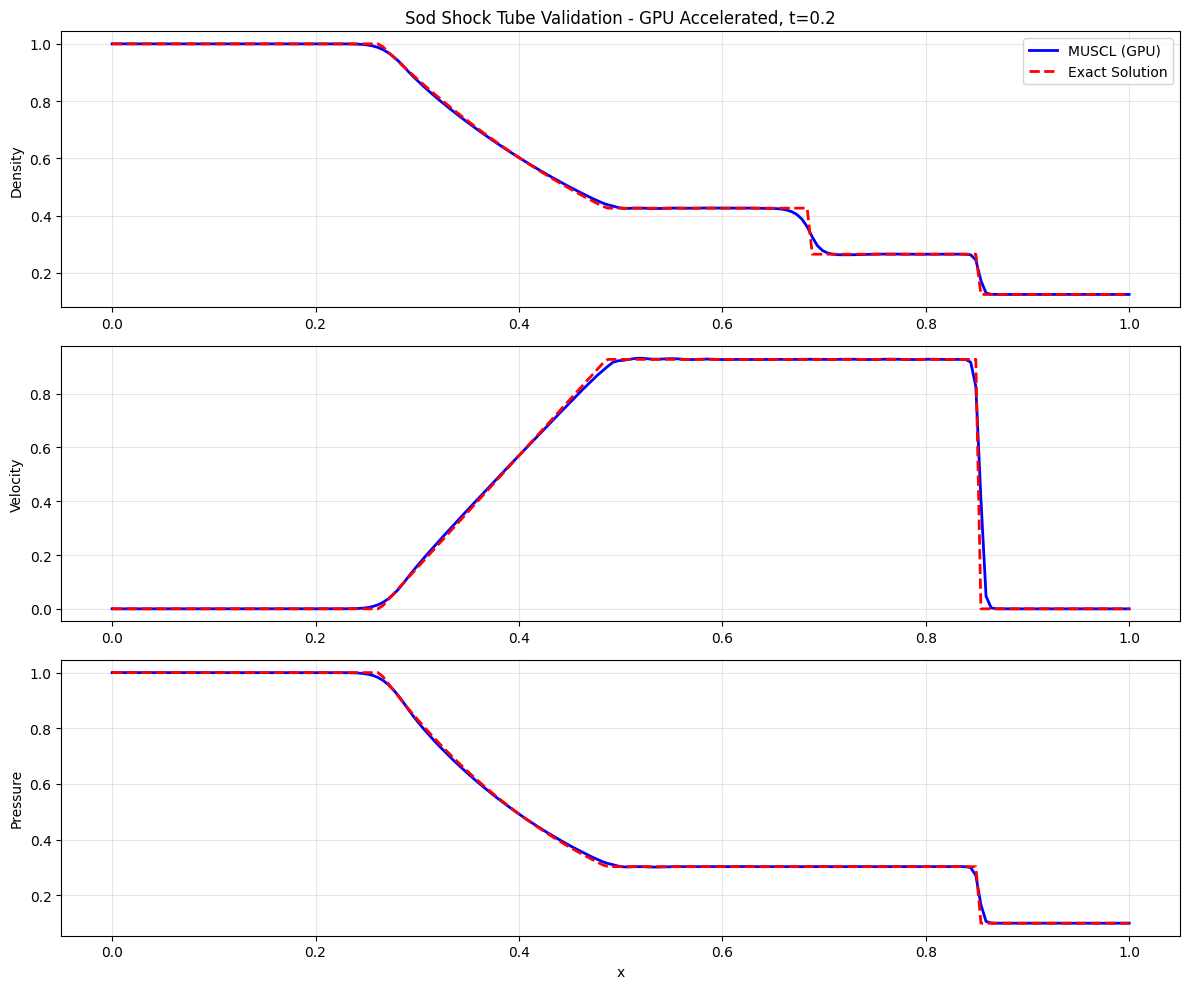


✓ Validation plot saved as 'validation.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm
import warp as wp

# Initialize Warp
wp.init()
# Select GPU if available, else fallback to CPU backend for Warp
device = "cuda" if wp.is_cuda_available() else "cpu"

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 200, 100  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Set to False for speed
PLOT_EVERY_N_STEPS = 50  # Plot less frequently for speed
PRINT_EVERY_N_STEPS = 20  # Print progress
USE_FASTER_PLOTTING = True  # Use simpler plots for speed

# ============================================
# INITIAL CONDITION (NumPy)
# ============================================

U_np = np.zeros((4, Nx, Ny), dtype=np.float32)

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U_np[0,i,j] = rho
        U_np[1,i,j] = rho*u
        U_np[2,i,j] = rho*v
        U_np[3,i,j] = p/(gamma-1.0) + 0.5*rho*(u*u+v*v)

# Convert to (Nx, Ny, 4) layout for Warp's vec4f
U_initial = np.transpose(U_np, (1, 2, 0)).copy()

# ============================================
# WARP KERNELS & FUNCTIONS
# ============================================

@wp.func
def cons_to_prim(U: wp.vec4f, gamma: float, EPS: float):
    rho = wp.max(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = wp.max((gamma - 1.0) * (E - 0.5 * rho * (u * u + v * v)), EPS)
    return rho, u, v, p

@wp.func
def prim_to_cons(rho: float, u: float, v: float, p: float, gamma: float):
    E = p / (gamma - 1.0) + 0.5 * rho * (u * u + v * v)
    return wp.vec4f(rho, rho * u, rho * v, E)

@wp.func
def minmod(a: float, b: float):
    if a * b <= 0.0:
        return 0.0
    if a > 0.0:
        return wp.min(a, b)
    else:
        return wp.max(a, b)

@wp.func
def reconstruct_state(U_m1: wp.vec4f, U_0: wp.vec4f, U_p1: wp.vec4f, U_p2: wp.vec4f, gamma: float, EPS: float):
    rho_m1, u_m1, v_m1, p_m1 = cons_to_prim(U_m1, gamma, EPS)
    rho_0,  u_0,  v_0,  p_0  = cons_to_prim(U_0, gamma, EPS)
    rho_p1, u_p1, v_p1, p_p1 = cons_to_prim(U_p1, gamma, EPS)
    rho_p2, u_p2, v_p2, p_p2 = cons_to_prim(U_p2, gamma, EPS)

    # Left state
    rho_L = rho_0 + 0.5 * minmod(rho_0 - rho_m1, rho_p1 - rho_0)
    u_L   = u_0   + 0.5 * minmod(u_0 - u_m1, u_p1 - u_0)
    v_L   = v_0   + 0.5 * minmod(v_0 - v_m1, v_p1 - v_0)
    p_L   = p_0   + 0.5 * minmod(p_0 - p_m1, p_p1 - p_0)

    # Right state
    rho_R = rho_p1 - 0.5 * minmod(rho_p1 - rho_0, rho_p2 - rho_p1)
    u_R   = u_p1   - 0.5 * minmod(u_p1 - u_0, u_p2 - u_p1)
    v_R   = v_p1   - 0.5 * minmod(v_p1 - v_0, v_p2 - v_p1)
    p_R   = p_p1   - 0.5 * minmod(p_p1 - p_0, p_p2 - p_p1)

    UL = prim_to_cons(rho_L, u_L, v_L, p_L, gamma)
    UR = prim_to_cons(rho_R, u_R, v_R, p_R, gamma)
    return UL, UR

@wp.func
def hllc_flux(UL: wp.vec4f, UR: wp.vec4f, gamma: float, EPS: float, dir_y: int):
    if dir_y == 1:
        UL = wp.vec4f(UL[0], UL[2], UL[1], UL[3])
        UR = wp.vec4f(UR[0], UR[2], UR[1], UR[3])

    rhoL = wp.max(UL[0], EPS)
    uL = UL[1] / rhoL
    vL = UL[2] / rhoL
    pL = wp.max((gamma - 1.0) * (UL[3] - 0.5 * rhoL * (uL * uL + vL * vL)), EPS)

    rhoR = wp.max(UR[0], EPS)
    uR = UR[1] / rhoR
    vR = UR[2] / rhoR
    pR = wp.max((gamma - 1.0) * (UR[3] - 0.5 * rhoR * (uR * uR + vR * vR)), EPS)

    cL = wp.sqrt(gamma * pL / rhoL)
    cR = wp.sqrt(gamma * pR / rhoR)

    sqrt_rhoL = wp.sqrt(rhoL)
    sqrt_rhoR = wp.sqrt(rhoR)
    u_avg = (sqrt_rhoL * uL + sqrt_rhoR * uR) / (sqrt_rhoL + sqrt_rhoR)
    c_avg = wp.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = wp.min(uL - cL, u_avg - c_avg)
    SR = wp.max(uR + cR, u_avg + c_avg)

    FL = wp.vec4f(rhoL * uL, rhoL * uL * uL + pL, rhoL * uL * vL, uL * (UL[3] + pL))
    FR = wp.vec4f(rhoR * uR, rhoR * uR * uR + pR, rhoR * uR * vR, uR * (UR[3] + pR))

    flux = wp.vec4f(0.0, 0.0, 0.0, 0.0)
    if SL >= 0.0:
        flux = FL
    elif SR <= 0.0:
        flux = FR
    else:
        flux = (SR * FL - SL * FR + SL * SR * (UR - UL)) / (SR - SL)

    if dir_y == 1:
        flux = wp.vec4f(flux[0], flux[2], flux[1], flux[3])

    return flux

@wp.kernel
def apply_bc_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    src_i = i
    src_j = j

    if i < NG: src_i = NG
    elif i >= Nx - NG: src_i = Nx - NG - 1

    if j < NG: src_j = NG
    elif j >= Ny - NG: src_j = Ny - NG - 1

    if i != src_i or j != src_j:
        U[i, j] = U[src_i, src_j]

@wp.kernel
def compute_max_speed_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), max_speed_arr: wp.array(dtype=float), gamma: float, EPS: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rho, u, v, p = cons_to_prim(U[i, j], gamma, EPS)
        c = wp.sqrt(gamma * p / rho)
        speed = wp.abs(u) + wp.abs(v) + c
        wp.atomic_max(max_speed_arr, 0, speed)

@wp.kernel
def compute_fluxes_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), gamma: float, EPS: float, use_muscl: int, Nx: int, Ny: int):
    i, j = wp.tid()

    # X-flux at interface (i+1/2, j)
    if i >= 1 and i <= Nx - 3 and j >= 1 and j <= Ny - 2:
        if use_muscl == 1:
            UL_x, UR_x = reconstruct_state(U[i-1, j], U[i, j], U[i+1, j], U[i+2, j], gamma, EPS)
        else:
            UL_x = U[i, j]
            UR_x = U[i+1, j]
        Fx[i, j] = hllc_flux(UL_x, UR_x, gamma, EPS, 0)

    # Y-flux at interface (i, j+1/2)
    if i >= 1 and i <= Nx - 2 and j >= 1 and j <= Ny - 3:
        if use_muscl == 1:
            UL_y, UR_y = reconstruct_state(U[i, j-1], U[i, j], U[i, j+1], U[i, j+2], gamma, EPS)
        else:
            UL_y = U[i, j]
            UR_y = U[i, j+1]
        Fy[i, j] = hllc_flux(UL_y, UR_y, gamma, EPS, 1)

@wp.kernel
def compute_rhs_kernel(Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), dx: float, dy: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rhs[i, j] = (Fx[i-1, j] - Fx[i, j]) / dx + (Fy[i, j-1] - Fy[i, j]) / dy

@wp.kernel
def euler_step_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step1_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U1[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step2_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), rhs1: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = 0.5 * (U[i, j] + U1[i, j] + rhs1[i, j] * dt)

# ============================================
# UTILITY FUNCTIONS
# ============================================

def get_numpy_state(U_wp):
    # Retrieve from GPU and transpose back to (4, Nx, Ny)
    return U_wp.numpy().transpose((2, 0, 1))

def compute_mean_values_np(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    return np.mean(rho), np.mean(np.sqrt(u*u + v*v)), np.mean(p)

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i
        if p > p_i:
            return (p - p_i) * np.sqrt(A / (p + B))
        else:
            return (2 * np.sqrt(gamma * p_i / rho) / (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL, fR = f(p, rhoL, pL), f(p, rhoR, pR)
        func = fL + fR + uR - uL
        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp
        p -= func / df
        p = max(p, 1e-6)

    p_star, u_star = p, 0.5 * (uL + uR + f(p, rhoR, pR) - f(p, rhoL, pL))
    cL, cR = np.sqrt(gamma * pL / rhoL), np.sqrt(gamma * pR / rhoR)
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)

    rho, u, p_out = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i in range(len(x)):
        xi = (x[i] - 0.5) / t
        if xi < SHL: rho[i], u[i], p_out[i] = rhoL, uL, pL
        elif xi <= STL:
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i], u[i], p_out[i] = rhoL * (c_i/cL)**(2/(gamma-1)), u_i, pL * (c_i/cL)**(2*gamma/(gamma-1))
        elif xi < u_star: rho[i], u[i], p_out[i] = rhoL * (p_star/pL)**(1/gamma), u_star, p_star
        elif xi <= SR: rho[i], u[i], p_out[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) / ((gamma-1)/(gamma+1) * p_star/pR + 1)), u_star, p_star
        else: rho[i], u[i], p_out[i] = rhoR, uR, pR
    return rho, u, p_out

# Global figure for live plotting
fig_live = None
axes_live = None

def plot_live_fields(U, step, t):
    global fig_live, axes_live
    if fig_live is None:
        fig_live, axes_live = plt.subplots(2, 2, figsize=(10, 8))
        plt.ion()

    for ax in axes_live.flat: ax.clear()

    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    Mach = np.sqrt(u*u + v*v) / np.sqrt(gamma * p / rho)

    axes_live[0,0].imshow(rho.T, origin='lower', cmap='jet', extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,0].set_title(f'Density (t={t:.3f})')
    axes_live[0,1].imshow(p.T, origin='lower', cmap='jet', extent=[0, NX, 0, NY], aspect='auto')
    axes_live[0,1].set_title('Pressure')
    axes_live[1,0].imshow(Mach.T, origin='lower', cmap='jet', extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,0].set_title('Mach Number')

    grad_mag = np.sqrt(np.gradient(rho, axis=0)**2 + np.gradient(rho, axis=1)**2)
    schlieren = np.log10(grad_mag / np.max(grad_mag) + 1e-10)
    axes_live[1,1].imshow(schlieren.T, origin='lower', cmap='gray', extent=[0, NX, 0, NY], aspect='auto')
    axes_live[1,1].set_title('Schlieren')

    plt.suptitle(f'2D Flow - Step {step}, GPU Accelerated')
    plt.tight_layout()
    plt.draw()
    plt.pause(0.01)

# ============================================
# MAIN GPU SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()} (GPU - {device})")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print("="*50)

# Allocate Warp Arrays
U_wp = wp.array(U_initial, dtype=wp.vec4f, device=device)
U_new_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
U1_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fx_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fy_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
rhs_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
max_speed_arr = wp.zeros(1, dtype=float, device=device)

use_muscl_flag = 1 if NUMERICAL_SCHEME == 'muscl' else 0

start_time = time.time()
t = 0.0
step = 0

estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))
print(f"Estimated total steps: ~{estimated_steps}")
print("="*50)

while t < t_final:
    wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U_wp, NG, Nx, Ny], device=device)

    # Calculate dt dynamically via atomic reduction
    max_speed_arr.fill_(0.0)
    wp.launch(compute_max_speed_kernel, dim=(Nx, Ny), inputs=[U_wp, max_speed_arr, gamma, EPS, NG, Nx, Ny], device=device)
    max_speed = max_speed_arr.numpy()[0]
    dt = CFL * min(dx, dy) / max_speed
    if t + dt > t_final: dt = t_final - t

    if TIME_STEPPING == 'euler':
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(euler_step_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    elif TIME_STEPPING == 'rk2':
        # RK2 Step 1
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step1_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U1_wp, float(dt)], device=device)
        wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U1_wp, NG, Nx, Ny], device=device)

        # RK2 Step 2 (SSPRK2)
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U1_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step2_kernel, dim=(Nx, Ny), inputs=[U_wp, U1_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    t += dt
    step += 1

    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        U_np = get_numpy_state(U_wp)
        rho_mean, u_mean, p_mean = compute_mean_values_np(U_np)
        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | p={p_mean:.4f} | speed={steps_per_sec:.1f} steps/s")

    if SHOW_LIVE_PLOTS and step % PLOT_EVERY_N_STEPS == 0:
        plot_live_fields(get_numpy_state(U_wp), step, t)

end_time = time.time()
print("="*50)
print(f"Completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# VALIDATION WITH EXACT SOLUTION (CPU)
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

U_final = get_numpy_state(U_wp)
j_mid = Ny // 2
rho_num = U_final[0, NG:-NG, j_mid]
u_num = U_final[1, NG:-NG, j_mid] / rho_num
p_num = (gamma-1)*(U_final[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {np.mean(np.abs(rho_num - rho_ex)):.6f}")
print(f"  Velocity: {np.mean(np.abs(u_num - u_ex)):.6f}")
print(f"  Pressure: {np.mean(np.abs(p_num - p_ex)):.6f}")

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - GPU Accelerated, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity'); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure'); plt.xlabel('x'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")

### 80X10

Grid: 80×10
Scheme: MUSCL (GPU - cuda)
Time stepping: EULER
Estimated total steps: ~19
Step     20 | t=0.05034/0.2 | dt=0.00224 | ρ=0.5625 | p=0.5432 | speed=2191.7 steps/s
Step     40 | t=0.09481/0.2 | dt=0.00223 | ρ=0.5625 | p=0.5368 | speed=2910.6 steps/s
Step     60 | t=0.13998/0.2 | dt=0.00226 | ρ=0.5625 | p=0.5302 | speed=3254.6 steps/s
Step     80 | t=0.18514/0.2 | dt=0.00226 | ρ=0.5625 | p=0.5236 | speed=3430.2 steps/s
Simulation completed in 0.03 seconds
Total steps: 87
Average speed: 3418.9 steps/second

CREATING FINAL PLOTS


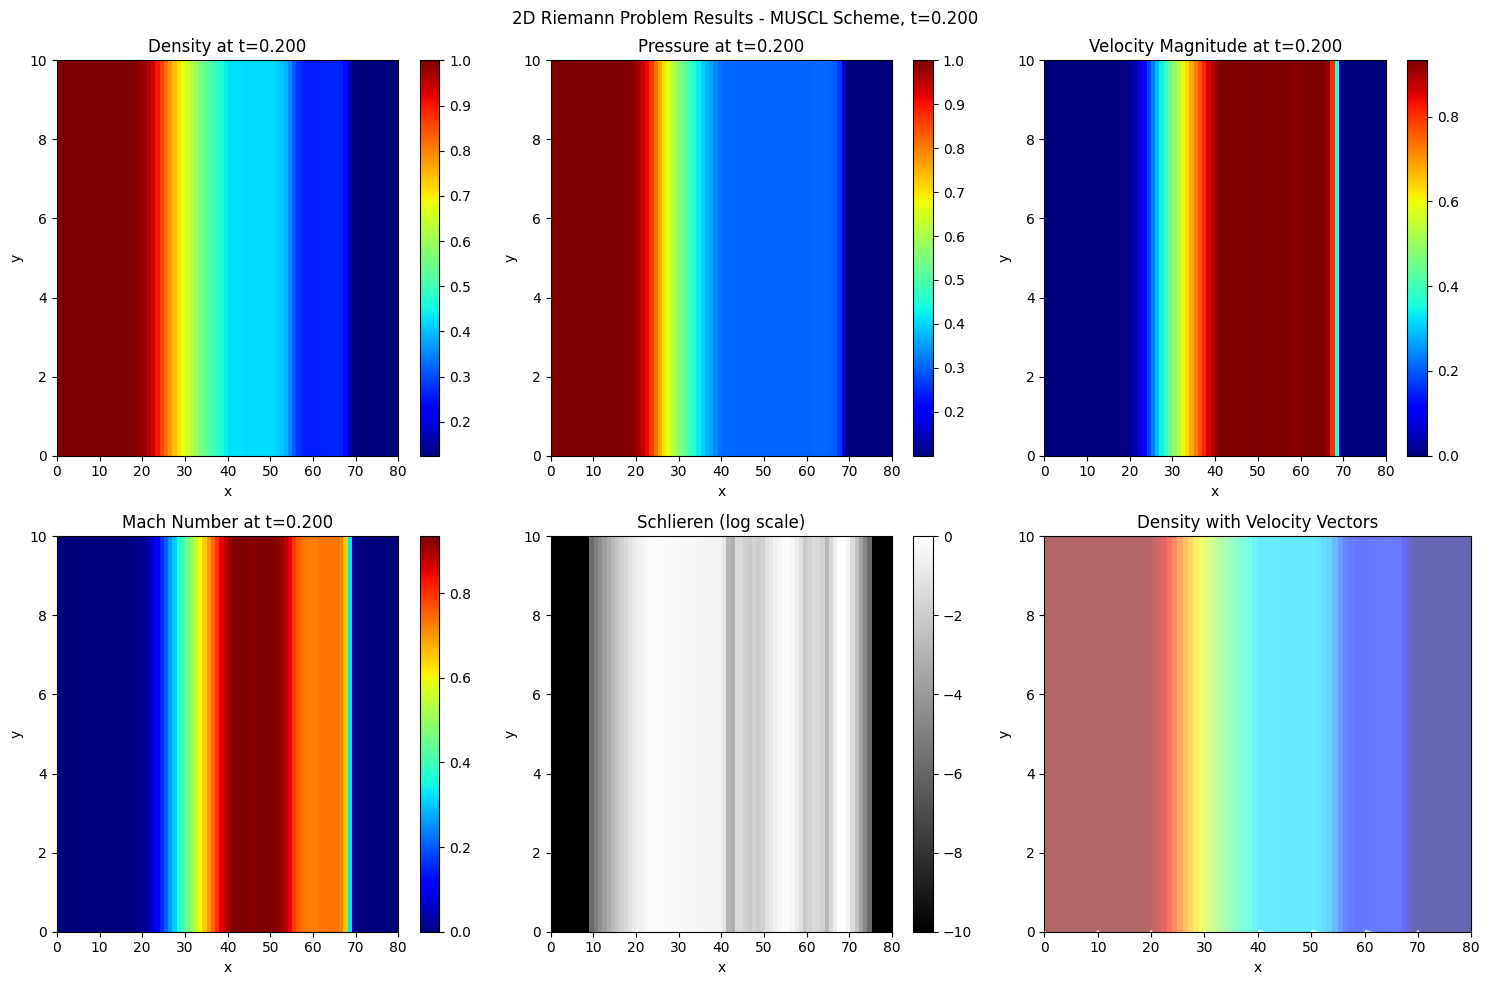

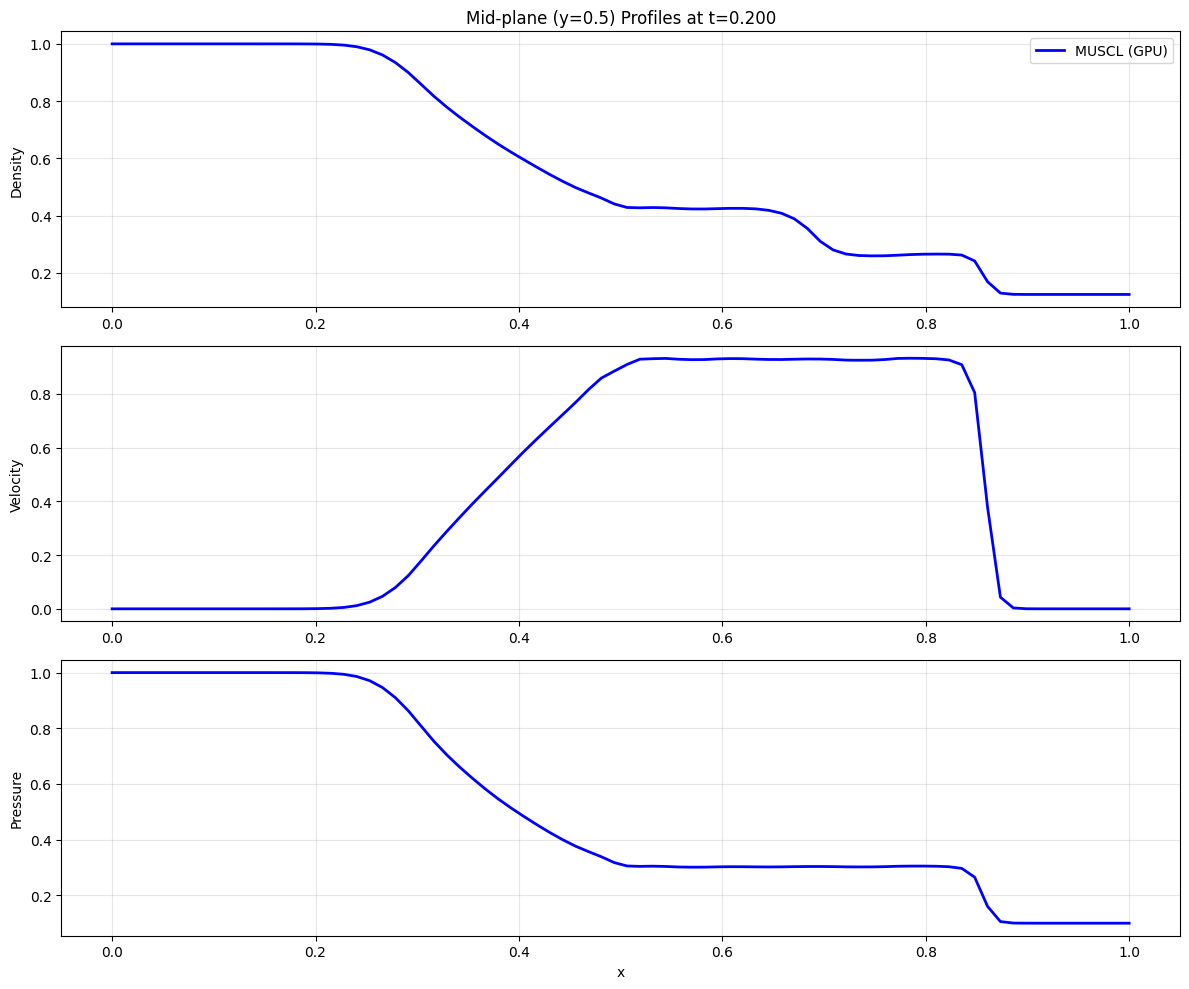


✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'

VALIDATION WITH EXACT SOD SOLUTION

L1 Errors at t=0.2:
  Density:  0.006957
  Velocity: 0.013030
  Pressure: 0.005394


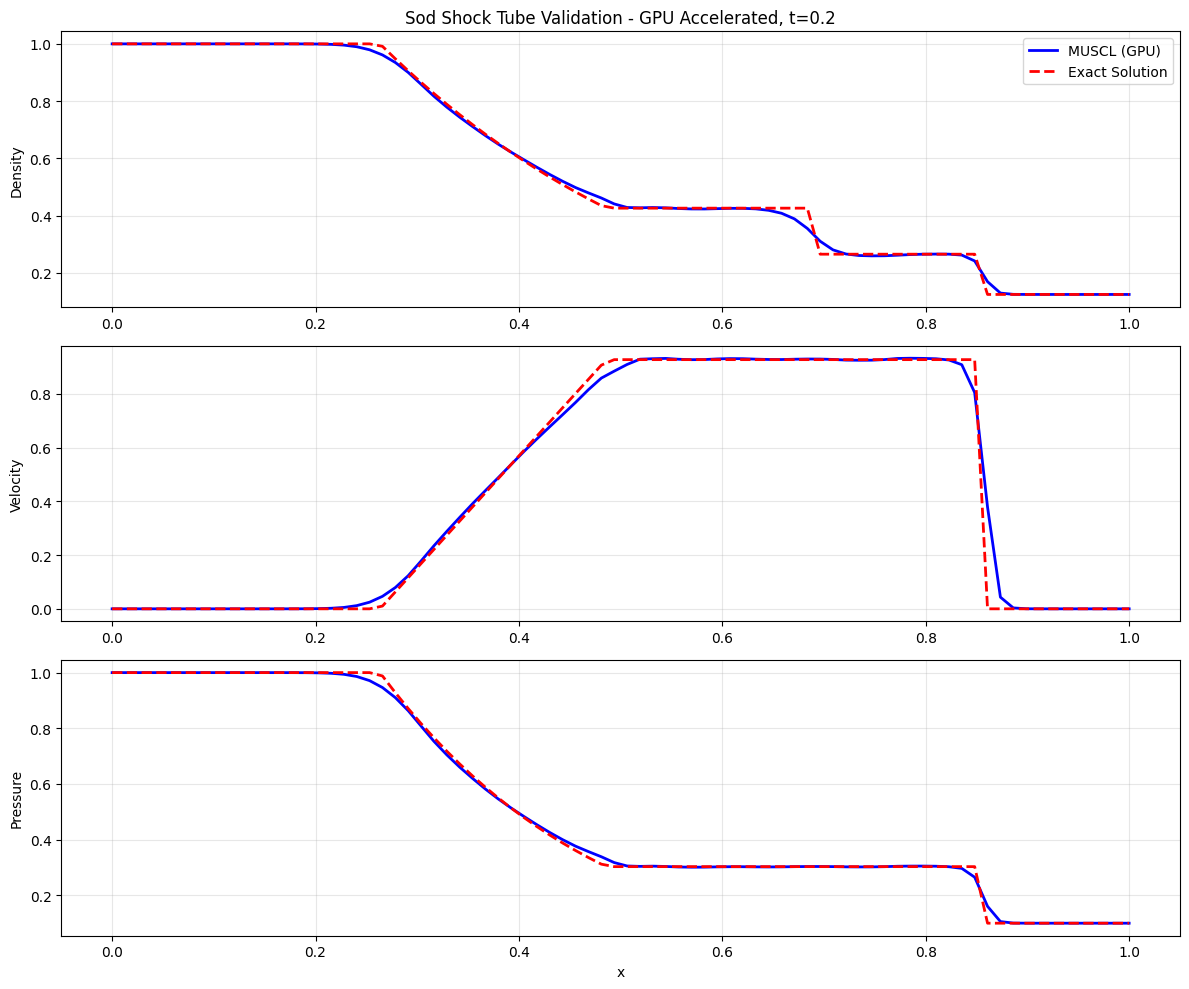


✓ Validation plot saved as 'validation.png'

All plots generated successfully!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm
import warp as wp

# Initialize Warp
#wp.clear_kernel_cache()
wp.init()
# Select GPU if available, else fallback to CPU backend for Warp
device = "cuda" if wp.is_cuda_available() else "cpu"

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 80, 10  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Keep False to avoid live plotting overhead
PRINT_EVERY_N_STEPS = 20  # Print progress

# ============================================
# INITIAL CONDITION (NumPy)
# ============================================

U_np = np.zeros((4, Nx, Ny), dtype=np.float32)

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U_np[0,i,j] = rho
        U_np[1,i,j] = rho*u
        U_np[2,i,j] = rho*v
        U_np[3,i,j] = p/(gamma-1.0) + 0.5*rho*(u*u+v*v)

# Convert to (Nx, Ny, 4) layout for Warp's vec4f
U_initial = np.transpose(U_np, (1, 2, 0)).copy()

# ============================================
# WARP KERNELS & FUNCTIONS
# ============================================

@wp.func
def cons_to_prim(U: wp.vec4f, gamma: float, EPS: float):
    rho = wp.max(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = wp.max((gamma - 1.0) * (E - 0.5 * rho * (u * u + v * v)), EPS)
    return rho, u, v, p

@wp.func
def prim_to_cons(rho: float, u: float, v: float, p: float, gamma: float):
    E = p / (gamma - 1.0) + 0.5 * rho * (u * u + v * v)
    return wp.vec4f(rho, rho * u, rho * v, E)

@wp.func
def minmod(a: float, b: float):
    if a * b <= 0.0:
        return 0.0
    if a > 0.0:
        return wp.min(a, b)
    else:
        return wp.max(a, b)

@wp.func
def reconstruct_state(U_m1: wp.vec4f, U_0: wp.vec4f, U_p1: wp.vec4f, U_p2: wp.vec4f, gamma: float, EPS: float):
    rho_m1, u_m1, v_m1, p_m1 = cons_to_prim(U_m1, gamma, EPS)
    rho_0,  u_0,  v_0,  p_0  = cons_to_prim(U_0, gamma, EPS)
    rho_p1, u_p1, v_p1, p_p1 = cons_to_prim(U_p1, gamma, EPS)
    rho_p2, u_p2, v_p2, p_p2 = cons_to_prim(U_p2, gamma, EPS)

    # Left state
    rho_L = rho_0 + 0.5 * minmod(rho_0 - rho_m1, rho_p1 - rho_0)
    u_L   = u_0   + 0.5 * minmod(u_0 - u_m1, u_p1 - u_0)
    v_L   = v_0   + 0.5 * minmod(v_0 - v_m1, v_p1 - v_0)
    p_L   = p_0   + 0.5 * minmod(p_0 - p_m1, p_p1 - p_0)

    # Right state
    rho_R = rho_p1 - 0.5 * minmod(rho_p1 - rho_0, rho_p2 - rho_p1)
    u_R   = u_p1   - 0.5 * minmod(u_p1 - u_0, u_p2 - u_p1)
    v_R   = v_p1   - 0.5 * minmod(v_p1 - v_0, v_p2 - v_p1)
    p_R   = p_p1   - 0.5 * minmod(p_p1 - p_0, p_p2 - p_p1)

    UL = prim_to_cons(rho_L, u_L, v_L, p_L, gamma)
    UR = prim_to_cons(rho_R, u_R, v_R, p_R, gamma)
    return UL, UR

@wp.func
def hllc_flux(UL: wp.vec4f, UR: wp.vec4f, gamma: float, EPS: float, dir_y: int):
    if dir_y == 1:
        UL = wp.vec4f(UL[0], UL[2], UL[1], UL[3])
        UR = wp.vec4f(UR[0], UR[2], UR[1], UR[3])

    rhoL = wp.max(UL[0], EPS)
    uL = UL[1] / rhoL
    vL = UL[2] / rhoL
    pL = wp.max((gamma - 1.0) * (UL[3] - 0.5 * rhoL * (uL * uL + vL * vL)), EPS)

    rhoR = wp.max(UR[0], EPS)
    uR = UR[1] / rhoR
    vR = UR[2] / rhoR
    pR = wp.max((gamma - 1.0) * (UR[3] - 0.5 * rhoR * (uR * uR + vR * vR)), EPS)

    cL = wp.sqrt(gamma * pL / rhoL)
    cR = wp.sqrt(gamma * pR / rhoR)

    sqrt_rhoL = wp.sqrt(rhoL)
    sqrt_rhoR = wp.sqrt(rhoR)
    u_avg = (sqrt_rhoL * uL + sqrt_rhoR * uR) / (sqrt_rhoL + sqrt_rhoR)
    c_avg = wp.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = wp.min(uL - cL, u_avg - c_avg)
    SR = wp.max(uR + cR, u_avg + c_avg)

    FL = wp.vec4f(rhoL * uL, rhoL * uL * uL + pL, rhoL * uL * vL, uL * (UL[3] + pL))
    FR = wp.vec4f(rhoR * uR, rhoR * uR * uR + pR, rhoR * uR * vR, uR * (UR[3] + pR))

    flux = wp.vec4f(0.0, 0.0, 0.0, 0.0)
    if SL >= 0.0:
        flux = FL
    elif SR <= 0.0:
        flux = FR
    else:
        flux = (SR * FL - SL * FR + SL * SR * (UR - UL)) / (SR - SL)

    if dir_y == 1:
        flux = wp.vec4f(flux[0], flux[2], flux[1], flux[3])

    return flux

@wp.kernel
def apply_bc_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    src_i = i
    src_j = j

    if i < NG: src_i = NG
    elif i >= Nx - NG: src_i = Nx - NG - 1

    if j < NG: src_j = NG
    elif j >= Ny - NG: src_j = Ny - NG - 1

    if i != src_i or j != src_j:
        U[i, j] = U[src_i, src_j]

@wp.kernel
def compute_max_speed_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), max_speed_arr: wp.array(dtype=float), gamma: float, EPS: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rho, u, v, p = cons_to_prim(U[i, j], gamma, EPS)
        c = wp.sqrt(gamma * p / rho)
        speed = wp.abs(u) + wp.abs(v) + c
        wp.atomic_max(max_speed_arr, 0, speed)

@wp.kernel
def compute_fluxes_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), gamma: float, EPS: float, use_muscl: int, Nx: int, Ny: int):
    i, j = wp.tid()

    # X-flux at interface (i+1/2, j)
    if i >= 1 and i <= Nx - 3 and j >= 1 and j <= Ny - 2:
        if use_muscl == 1:
            UL_x, UR_x = reconstruct_state(U[i-1, j], U[i, j], U[i+1, j], U[i+2, j], gamma, EPS)
        else:
            UL_x = U[i, j]
            UR_x = U[i+1, j]
        Fx[i, j] = hllc_flux(UL_x, UR_x, gamma, EPS, 0)

    # Y-flux at interface (i, j+1/2)
    if i >= 1 and i <= Nx - 2 and j >= 1 and j <= Ny - 3:
        if use_muscl == 1:
            UL_y, UR_y = reconstruct_state(U[i, j-1], U[i, j], U[i, j+1], U[i, j+2], gamma, EPS)
        else:
            UL_y = U[i, j]
            UR_y = U[i, j+1]
        Fy[i, j] = hllc_flux(UL_y, UR_y, gamma, EPS, 1)

@wp.kernel
def compute_rhs_kernel(Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), dx: float, dy: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rhs[i, j] = (Fx[i-1, j] - Fx[i, j]) / dx + (Fy[i, j-1] - Fy[i, j]) / dy

@wp.kernel
def euler_step_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step1_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U1[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step2_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), rhs1: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = 0.5 * (U[i, j] + U1[i, j] + rhs1[i, j] * dt)

# ============================================
# UTILITY FUNCTIONS
# ============================================

def get_numpy_state(U_wp):
    # Retrieve from GPU and transpose back to (4, Nx, Ny)
    return U_wp.numpy().transpose((2, 0, 1))

def compute_mean_values_np(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    return np.mean(rho), np.mean(np.sqrt(u*u + v*v)), np.mean(p)

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i
        if p > p_i:
            return (p - p_i) * np.sqrt(A / (p + B))
        else:
            return (2 * np.sqrt(gamma * p_i / rho) / (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL, fR = f(p, rhoL, pL), f(p, rhoR, pR)
        func = fL + fR + uR - uL
        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp
        p -= func / df
        p = max(p, 1e-6)

    p_star, u_star = p, 0.5 * (uL + uR + f(p, rhoR, pR) - f(p, rhoL, pL))
    cL, cR = np.sqrt(gamma * pL / rhoL), np.sqrt(gamma * pR / rhoR)
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)

    rho, u, p_out = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i in range(len(x)):
        xi = (x[i] - 0.5) / t
        if xi < SHL: rho[i], u[i], p_out[i] = rhoL, uL, pL
        elif xi <= STL:
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i], u[i], p_out[i] = rhoL * (c_i/cL)**(2/(gamma-1)), u_i, pL * (c_i/cL)**(2*gamma/(gamma-1))
        elif xi < u_star: rho[i], u[i], p_out[i] = rhoL * (p_star/pL)**(1/gamma), u_star, p_star
        elif xi <= SR: rho[i], u[i], p_out[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) / ((gamma-1)/(gamma+1) * p_star/pR + 1)), u_star, p_star
        else: rho[i], u[i], p_out[i] = rhoR, uR, pR
    return rho, u, p_out

def plot_final_results(U, t_final, gamma, NG, NX, NY):
    """Create comprehensive final plots after simulation"""

    # Extract fields
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / (rho + 1e-10)
    v = U[2, NG:-NG, NG:-NG] / (rho + 1e-10)
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, 1e-6)  # Avoid negative pressure

    # Mach number
    c = np.sqrt(gamma * p / (rho + 1e-10))
    Mach = np.sqrt(u*u + v*v) / (c + 1e-10)

    # Schlieren (gradient of density)
    grad_x = np.gradient(rho, axis=0)
    grad_y = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    schlieren = np.log10(grad_mag / (np.max(grad_mag) + 1e-10) + 1e-10)

    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot 1: Density
    im1 = axes[0,0].imshow(rho.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,0].set_title(f'Density at t={t_final:.3f}')
    axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0,0])

    # Plot 2: Pressure
    im2 = axes[0,1].imshow(p.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,1].set_title(f'Pressure at t={t_final:.3f}')
    axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0,1])

    # Plot 3: Velocity magnitude
    vel_mag = np.sqrt(u**2 + v**2)
    im3 = axes[0,2].imshow(vel_mag.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,2].set_title(f'Velocity Magnitude at t={t_final:.3f}')
    axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('y')
    plt.colorbar(im3, ax=axes[0,2])

    # Plot 4: Mach Number
    im4 = axes[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,0].set_title(f'Mach Number at t={t_final:.3f}')
    axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1,0])

    # Plot 5: Schlieren
    im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,1].set_title('Schlieren (log scale)')
    axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
    plt.colorbar(im5, ax=axes[1,1])

    # Plot 6: Streamlines or velocity vectors (simplified)
    # Downsample for clarity
    stride = 10
    X, Y = np.meshgrid(np.arange(0, NX, stride), np.arange(0, NY, stride))
    U_ds = u[::stride, ::stride]
    V_ds = v[::stride, ::stride]
    axes[1,2].imshow(rho.T, origin='lower', cmap='jet', alpha=0.6,
                     extent=[0, NX, 0, NY], aspect='auto')
    axes[1,2].quiver(X, Y, U_ds.T, V_ds.T, alpha=0.8, color='white', scale=50)
    axes[1,2].set_title('Density with Velocity Vectors')
    axes[1,2].set_xlabel('x'); axes[1,2].set_ylabel('y')

    plt.suptitle(f'2D Riemann Problem Results - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final:.3f}')
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Also create a line plot at mid-plane for comparison
    j_mid = NY // 2
    rho_mid = U[0, NG:-NG, j_mid]
    u_mid = U[1, NG:-NG, j_mid] / (rho_mid + 1e-10)
    p_mid = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_mid*u_mid**2)

    x = np.linspace(0, 1, NX)

    plt.figure(figsize=(12, 10))
    plt.subplot(3, 1, 1)
    plt.plot(x, rho_mid, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Mid-plane (y=0.5) Profiles at t={t_final:.3f}')

    plt.subplot(3, 1, 2)
    plt.plot(x, u_mid, 'b-', linewidth=2)
    plt.ylabel('Velocity')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(x, p_mid, 'b-', linewidth=2)
    plt.ylabel('Pressure')
    plt.xlabel('x')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('midplane_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'")

# ============================================
# MAIN GPU SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()} (GPU - {device})")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print("="*50)

# Allocate Warp Arrays
U_wp = wp.array(U_initial, dtype=wp.vec4f, device=device)
U_new_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
U1_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fx_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fy_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
rhs_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
max_speed_arr = wp.zeros(1, dtype=float, device=device)

use_muscl_flag = 1 if NUMERICAL_SCHEME == 'muscl' else 0

wp.synchronize()
start_time = time.time()
# start_time = time.time()
t = 0.0
step = 0

estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))
print(f"Estimated total steps: ~{estimated_steps}")
print("="*50)

# Run simulation without live plotting
while t < t_final:
    wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U_wp, NG, Nx, Ny], device=device)

    # Calculate dt dynamically via atomic reduction
    max_speed_arr.fill_(0.0)
    wp.launch(compute_max_speed_kernel, dim=(Nx, Ny), inputs=[U_wp, max_speed_arr, gamma, EPS, NG, Nx, Ny], device=device)
    max_speed = max_speed_arr.numpy()[0]
    dt = CFL * min(dx, dy) / max_speed
    if t + dt > t_final: dt = t_final - t

    if TIME_STEPPING == 'euler':
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(euler_step_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    elif TIME_STEPPING == 'rk2':
        # RK2 Step 1
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step1_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U1_wp, float(dt)], device=device)
        wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U1_wp, NG, Nx, Ny], device=device)

        # RK2 Step 2 (SSPRK2)
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U1_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step2_kernel, dim=(Nx, Ny), inputs=[U_wp, U1_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    t += dt
    step += 1

    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        U_np = get_numpy_state(U_wp)
        rho_mean, u_mean, p_mean = compute_mean_values_np(U_np)
        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | p={p_mean:.4f} | speed={steps_per_sec:.1f} steps/s")
wp.synchronize()
end_time = time.time()
print("="*50)
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# POST-PROCESSING: CREATE FINAL PLOTS
# ============================================

print("\n" + "="*50)
print("CREATING FINAL PLOTS")
print("="*50)

# Get final state
U_final = get_numpy_state(U_wp)

# Create comprehensive final plots
plot_final_results(U_final, t_final, gamma, NG, NX, NY)

# ============================================
# VALIDATION WITH EXACT SOLUTION (CPU)
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

j_mid = NY // 2
rho_num = U_final[0, NG:-NG, j_mid]
u_num = U_final[1, NG:-NG, j_mid] / (rho_num + 1e-10)
p_num = (gamma-1)*(U_final[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {np.mean(np.abs(rho_num - rho_ex)):.6f}")
print(f"  Velocity: {np.mean(np.abs(u_num - u_ex)):.6f}")
print(f"  Pressure: {np.mean(np.abs(p_num - p_ex)):.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - GPU Accelerated, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity'); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure'); plt.xlabel('x'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")
print("\nAll plots generated successfully!")

### 200X100

Grid: 200×100
Scheme: MUSCL (GPU - cuda)
Time stepping: EULER
Estimated total steps: ~50
Module __main__ 6124ca4 load on device 'cuda:0' took 3178.57 ms  (compiled)
Step     20 | t=0.02014/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5473 | speed=6.3 steps/s
Step     40 | t=0.03792/0.2 | dt=0.00089 | ρ=0.5625 | p=0.5447 | speed=12.5 steps/s
Step     60 | t=0.05599/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5421 | speed=18.7 steps/s
Step     80 | t=0.07405/0.2 | dt=0.00090 | ρ=0.5625 | p=0.5395 | speed=24.9 steps/s
Step    100 | t=0.09219/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5368 | speed=31.1 steps/s
Step    120 | t=0.11035/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5342 | speed=37.3 steps/s
Step    140 | t=0.12852/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5315 | speed=43.4 steps/s
Step    160 | t=0.14671/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5289 | speed=49.5 steps/s
Step    180 | t=0.16490/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5262 | speed=55.6 steps/s
Step    200 | t=0.18309/0.2 | dt=0.00091 | ρ=0.5625 | p=0.5236 | speed=61.7 step

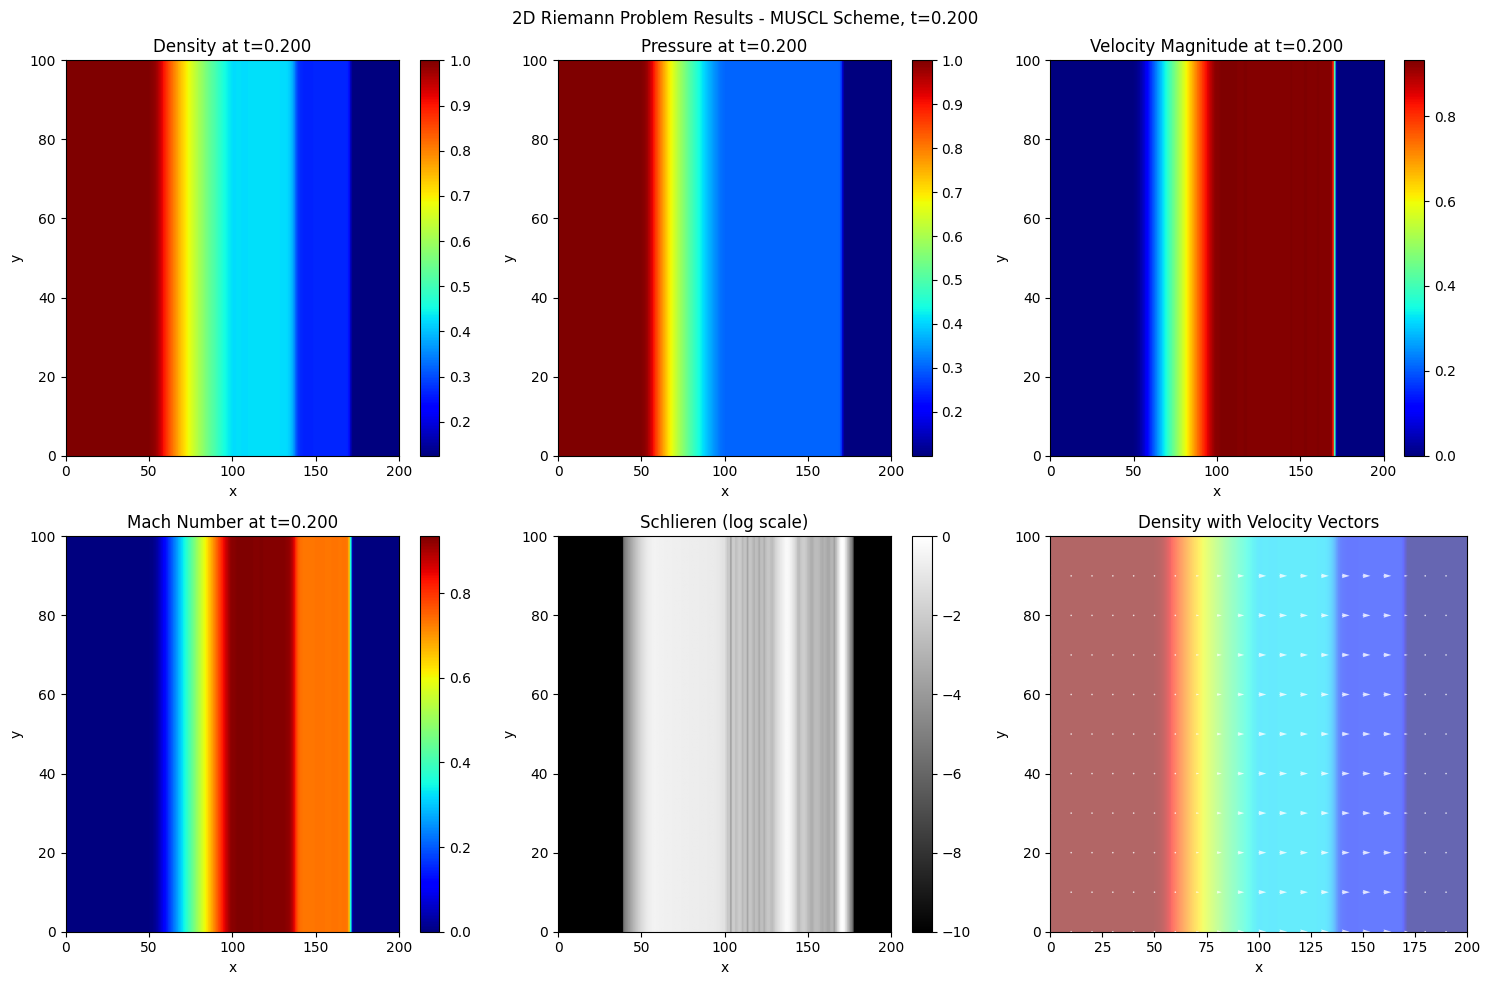

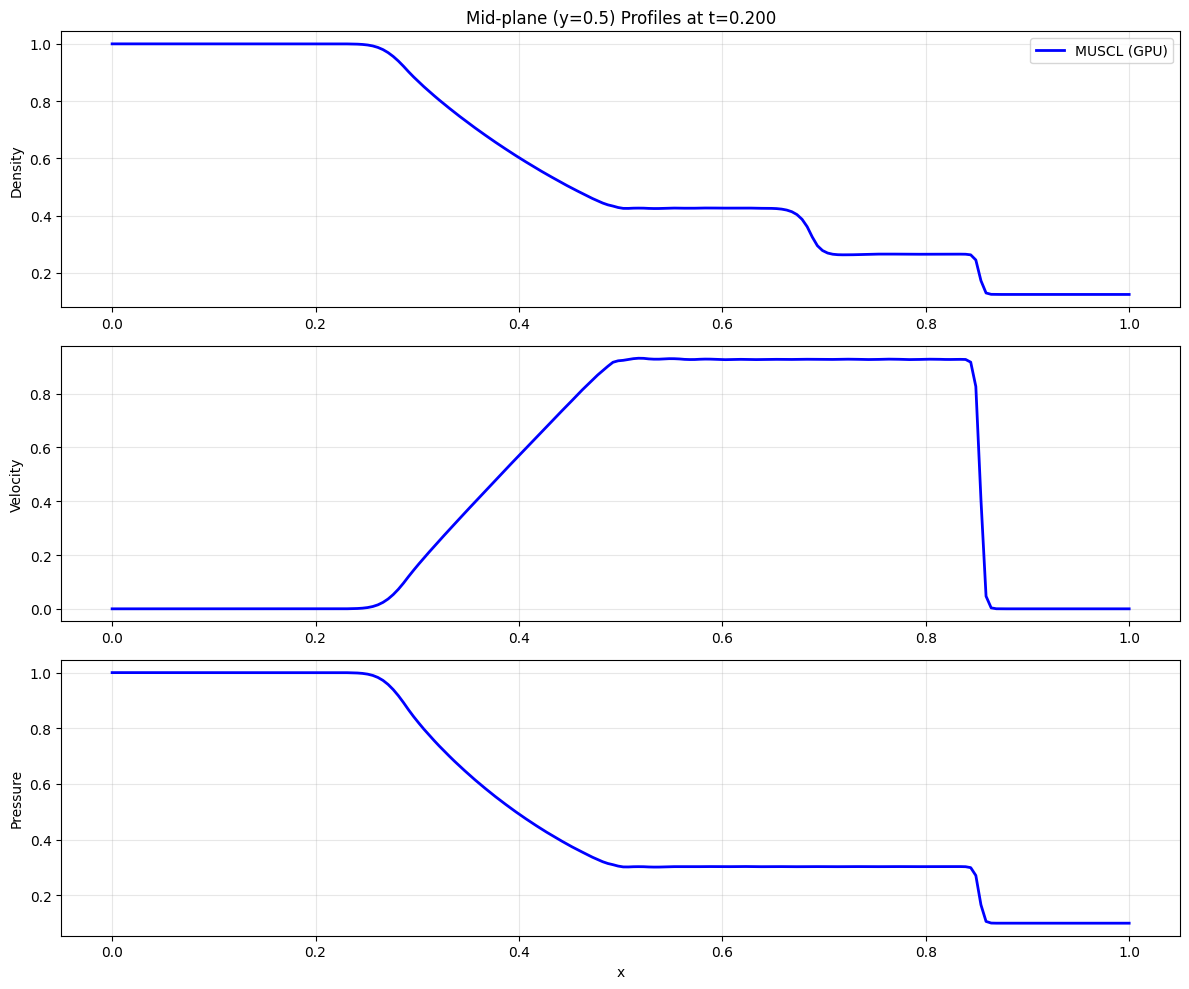


✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'

VALIDATION WITH EXACT SOD SOLUTION

L1 Errors at t=0.2:
  Density:  0.003054
  Velocity: 0.005214
  Pressure: 0.002120


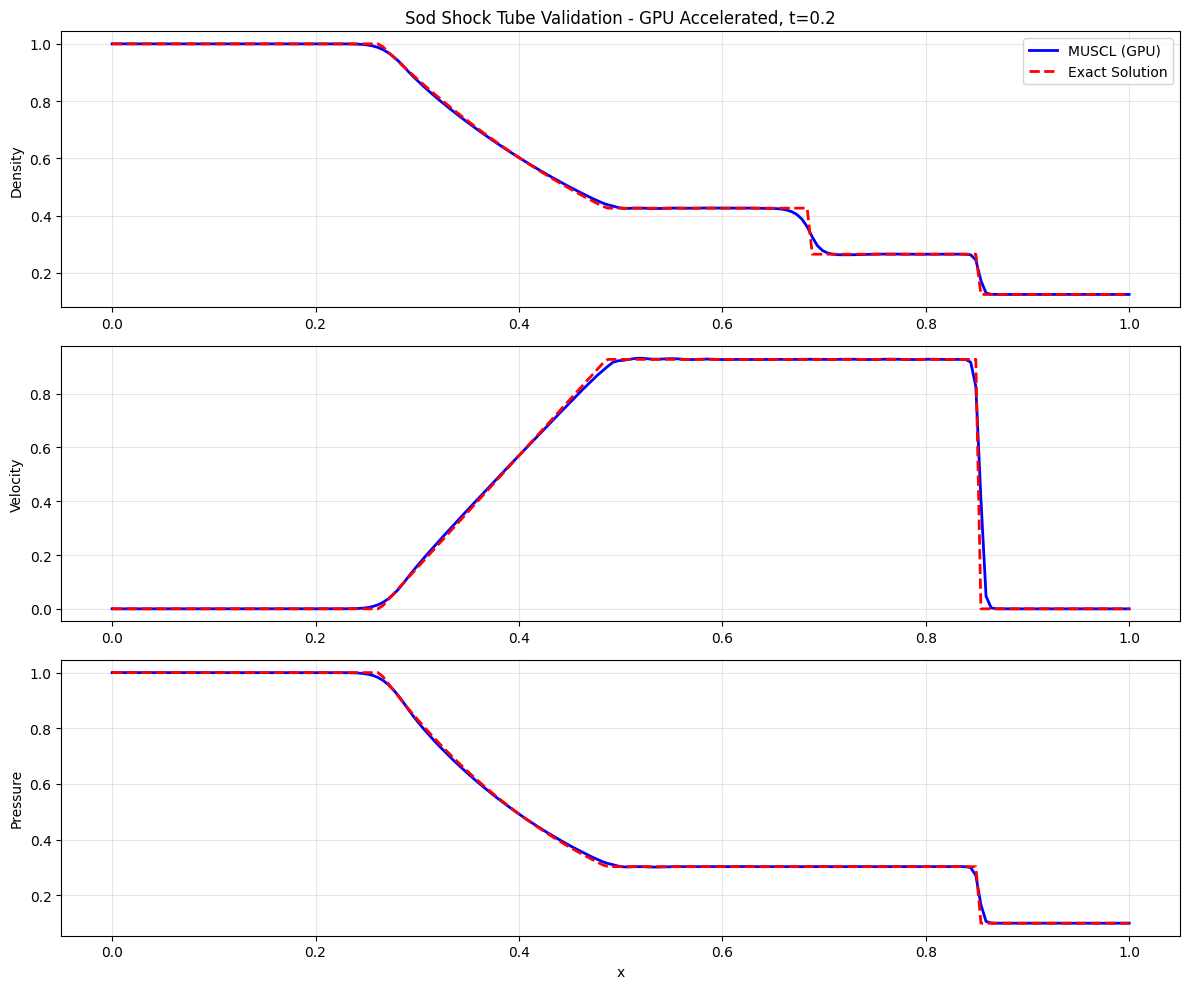


✓ Validation plot saved as 'validation.png'

All plots generated successfully!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm
import warp as wp

# Initialize Warp
# wp.clear_kernel_cache()
wp.init()
# Select GPU if available, else fallback to CPU backend for Warp
device = "cuda" if wp.is_cuda_available() else "cpu"

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 200, 100  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Keep False to avoid live plotting overhead
PRINT_EVERY_N_STEPS = 20  # Print progress

# ============================================
# INITIAL CONDITION (NumPy)
# ============================================

U_np = np.zeros((4, Nx, Ny), dtype=np.float32)

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U_np[0,i,j] = rho
        U_np[1,i,j] = rho*u
        U_np[2,i,j] = rho*v
        U_np[3,i,j] = p/(gamma-1.0) + 0.5*rho*(u*u+v*v)

# Convert to (Nx, Ny, 4) layout for Warp's vec4f
U_initial = np.transpose(U_np, (1, 2, 0)).copy()

# ============================================
# WARP KERNELS & FUNCTIONS
# ============================================

@wp.func
def cons_to_prim(U: wp.vec4f, gamma: float, EPS: float):
    rho = wp.max(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = wp.max((gamma - 1.0) * (E - 0.5 * rho * (u * u + v * v)), EPS)
    return rho, u, v, p

@wp.func
def prim_to_cons(rho: float, u: float, v: float, p: float, gamma: float):
    E = p / (gamma - 1.0) + 0.5 * rho * (u * u + v * v)
    return wp.vec4f(rho, rho * u, rho * v, E)

@wp.func
def minmod(a: float, b: float):
    if a * b <= 0.0:
        return 0.0
    if a > 0.0:
        return wp.min(a, b)
    else:
        return wp.max(a, b)

@wp.func
def reconstruct_state(U_m1: wp.vec4f, U_0: wp.vec4f, U_p1: wp.vec4f, U_p2: wp.vec4f, gamma: float, EPS: float):
    rho_m1, u_m1, v_m1, p_m1 = cons_to_prim(U_m1, gamma, EPS)
    rho_0,  u_0,  v_0,  p_0  = cons_to_prim(U_0, gamma, EPS)
    rho_p1, u_p1, v_p1, p_p1 = cons_to_prim(U_p1, gamma, EPS)
    rho_p2, u_p2, v_p2, p_p2 = cons_to_prim(U_p2, gamma, EPS)

    # Left state
    rho_L = rho_0 + 0.5 * minmod(rho_0 - rho_m1, rho_p1 - rho_0)
    u_L   = u_0   + 0.5 * minmod(u_0 - u_m1, u_p1 - u_0)
    v_L   = v_0   + 0.5 * minmod(v_0 - v_m1, v_p1 - v_0)
    p_L   = p_0   + 0.5 * minmod(p_0 - p_m1, p_p1 - p_0)

    # Right state
    rho_R = rho_p1 - 0.5 * minmod(rho_p1 - rho_0, rho_p2 - rho_p1)
    u_R   = u_p1   - 0.5 * minmod(u_p1 - u_0, u_p2 - u_p1)
    v_R   = v_p1   - 0.5 * minmod(v_p1 - v_0, v_p2 - v_p1)
    p_R   = p_p1   - 0.5 * minmod(p_p1 - p_0, p_p2 - p_p1)

    UL = prim_to_cons(rho_L, u_L, v_L, p_L, gamma)
    UR = prim_to_cons(rho_R, u_R, v_R, p_R, gamma)
    return UL, UR

@wp.func
def hllc_flux(UL: wp.vec4f, UR: wp.vec4f, gamma: float, EPS: float, dir_y: int):
    if dir_y == 1:
        UL = wp.vec4f(UL[0], UL[2], UL[1], UL[3])
        UR = wp.vec4f(UR[0], UR[2], UR[1], UR[3])

    rhoL = wp.max(UL[0], EPS)
    uL = UL[1] / rhoL
    vL = UL[2] / rhoL
    pL = wp.max((gamma - 1.0) * (UL[3] - 0.5 * rhoL * (uL * uL + vL * vL)), EPS)

    rhoR = wp.max(UR[0], EPS)
    uR = UR[1] / rhoR
    vR = UR[2] / rhoR
    pR = wp.max((gamma - 1.0) * (UR[3] - 0.5 * rhoR * (uR * uR + vR * vR)), EPS)

    cL = wp.sqrt(gamma * pL / rhoL)
    cR = wp.sqrt(gamma * pR / rhoR)

    sqrt_rhoL = wp.sqrt(rhoL)
    sqrt_rhoR = wp.sqrt(rhoR)
    u_avg = (sqrt_rhoL * uL + sqrt_rhoR * uR) / (sqrt_rhoL + sqrt_rhoR)
    c_avg = wp.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = wp.min(uL - cL, u_avg - c_avg)
    SR = wp.max(uR + cR, u_avg + c_avg)

    FL = wp.vec4f(rhoL * uL, rhoL * uL * uL + pL, rhoL * uL * vL, uL * (UL[3] + pL))
    FR = wp.vec4f(rhoR * uR, rhoR * uR * uR + pR, rhoR * uR * vR, uR * (UR[3] + pR))

    flux = wp.vec4f(0.0, 0.0, 0.0, 0.0)
    if SL >= 0.0:
        flux = FL
    elif SR <= 0.0:
        flux = FR
    else:
        flux = (SR * FL - SL * FR + SL * SR * (UR - UL)) / (SR - SL)

    if dir_y == 1:
        flux = wp.vec4f(flux[0], flux[2], flux[1], flux[3])

    return flux

@wp.kernel
def apply_bc_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    src_i = i
    src_j = j

    if i < NG: src_i = NG
    elif i >= Nx - NG: src_i = Nx - NG - 1

    if j < NG: src_j = NG
    elif j >= Ny - NG: src_j = Ny - NG - 1

    if i != src_i or j != src_j:
        U[i, j] = U[src_i, src_j]

@wp.kernel
def compute_max_speed_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), max_speed_arr: wp.array(dtype=float), gamma: float, EPS: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rho, u, v, p = cons_to_prim(U[i, j], gamma, EPS)
        c = wp.sqrt(gamma * p / rho)
        speed = wp.abs(u) + wp.abs(v) + c
        wp.atomic_max(max_speed_arr, 0, speed)

@wp.kernel
def compute_fluxes_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), gamma: float, EPS: float, use_muscl: int, Nx: int, Ny: int):
    i, j = wp.tid()

    # X-flux at interface (i+1/2, j)
    if i >= 1 and i <= Nx - 3 and j >= 1 and j <= Ny - 2:
        if use_muscl == 1:
            UL_x, UR_x = reconstruct_state(U[i-1, j], U[i, j], U[i+1, j], U[i+2, j], gamma, EPS)
        else:
            UL_x = U[i, j]
            UR_x = U[i+1, j]
        Fx[i, j] = hllc_flux(UL_x, UR_x, gamma, EPS, 0)

    # Y-flux at interface (i, j+1/2)
    if i >= 1 and i <= Nx - 2 and j >= 1 and j <= Ny - 3:
        if use_muscl == 1:
            UL_y, UR_y = reconstruct_state(U[i, j-1], U[i, j], U[i, j+1], U[i, j+2], gamma, EPS)
        else:
            UL_y = U[i, j]
            UR_y = U[i, j+1]
        Fy[i, j] = hllc_flux(UL_y, UR_y, gamma, EPS, 1)

@wp.kernel
def compute_rhs_kernel(Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), dx: float, dy: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rhs[i, j] = (Fx[i-1, j] - Fx[i, j]) / dx + (Fy[i, j-1] - Fy[i, j]) / dy

@wp.kernel
def euler_step_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step1_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U1[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step2_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), rhs1: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = 0.5 * (U[i, j] + U1[i, j] + rhs1[i, j] * dt)

# ============================================
# UTILITY FUNCTIONS
# ============================================

def get_numpy_state(U_wp):
    # Retrieve from GPU and transpose back to (4, Nx, Ny)
    return U_wp.numpy().transpose((2, 0, 1))

def compute_mean_values_np(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    return np.mean(rho), np.mean(np.sqrt(u*u + v*v)), np.mean(p)

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i
        if p > p_i:
            return (p - p_i) * np.sqrt(A / (p + B))
        else:
            return (2 * np.sqrt(gamma * p_i / rho) / (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL, fR = f(p, rhoL, pL), f(p, rhoR, pR)
        func = fL + fR + uR - uL
        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp
        p -= func / df
        p = max(p, 1e-6)

    p_star, u_star = p, 0.5 * (uL + uR + f(p, rhoR, pR) - f(p, rhoL, pL))
    cL, cR = np.sqrt(gamma * pL / rhoL), np.sqrt(gamma * pR / rhoR)
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)

    rho, u, p_out = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i in range(len(x)):
        xi = (x[i] - 0.5) / t
        if xi < SHL: rho[i], u[i], p_out[i] = rhoL, uL, pL
        elif xi <= STL:
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i], u[i], p_out[i] = rhoL * (c_i/cL)**(2/(gamma-1)), u_i, pL * (c_i/cL)**(2*gamma/(gamma-1))
        elif xi < u_star: rho[i], u[i], p_out[i] = rhoL * (p_star/pL)**(1/gamma), u_star, p_star
        elif xi <= SR: rho[i], u[i], p_out[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) / ((gamma-1)/(gamma+1) * p_star/pR + 1)), u_star, p_star
        else: rho[i], u[i], p_out[i] = rhoR, uR, pR
    return rho, u, p_out

def plot_final_results(U, t_final, gamma, NG, NX, NY):
    """Create comprehensive final plots after simulation"""

    # Extract fields
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / (rho + 1e-10)
    v = U[2, NG:-NG, NG:-NG] / (rho + 1e-10)
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, 1e-6)  # Avoid negative pressure

    # Mach number
    c = np.sqrt(gamma * p / (rho + 1e-10))
    Mach = np.sqrt(u*u + v*v) / (c + 1e-10)

    # Schlieren (gradient of density)
    grad_x = np.gradient(rho, axis=0)
    grad_y = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    schlieren = np.log10(grad_mag / (np.max(grad_mag) + 1e-10) + 1e-10)

    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot 1: Density
    im1 = axes[0,0].imshow(rho.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,0].set_title(f'Density at t={t_final:.3f}')
    axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0,0])

    # Plot 2: Pressure
    im2 = axes[0,1].imshow(p.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,1].set_title(f'Pressure at t={t_final:.3f}')
    axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0,1])

    # Plot 3: Velocity magnitude
    vel_mag = np.sqrt(u**2 + v**2)
    im3 = axes[0,2].imshow(vel_mag.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,2].set_title(f'Velocity Magnitude at t={t_final:.3f}')
    axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('y')
    plt.colorbar(im3, ax=axes[0,2])

    # Plot 4: Mach Number
    im4 = axes[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,0].set_title(f'Mach Number at t={t_final:.3f}')
    axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1,0])

    # Plot 5: Schlieren
    im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,1].set_title('Schlieren (log scale)')
    axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
    plt.colorbar(im5, ax=axes[1,1])

    # Plot 6: Streamlines or velocity vectors (simplified)
    # Downsample for clarity
    stride = 10
    X, Y = np.meshgrid(np.arange(0, NX, stride), np.arange(0, NY, stride))
    U_ds = u[::stride, ::stride]
    V_ds = v[::stride, ::stride]
    axes[1,2].imshow(rho.T, origin='lower', cmap='jet', alpha=0.6,
                     extent=[0, NX, 0, NY], aspect='auto')
    axes[1,2].quiver(X, Y, U_ds.T, V_ds.T, alpha=0.8, color='white', scale=50)
    axes[1,2].set_title('Density with Velocity Vectors')
    axes[1,2].set_xlabel('x'); axes[1,2].set_ylabel('y')

    plt.suptitle(f'2D Riemann Problem Results - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final:.3f}')
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Also create a line plot at mid-plane for comparison
    j_mid = NY // 2
    rho_mid = U[0, NG:-NG, j_mid]
    u_mid = U[1, NG:-NG, j_mid] / (rho_mid + 1e-10)
    p_mid = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_mid*u_mid**2)

    x = np.linspace(0, 1, NX)

    plt.figure(figsize=(12, 10))
    plt.subplot(3, 1, 1)
    plt.plot(x, rho_mid, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Mid-plane (y=0.5) Profiles at t={t_final:.3f}')

    plt.subplot(3, 1, 2)
    plt.plot(x, u_mid, 'b-', linewidth=2)
    plt.ylabel('Velocity')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(x, p_mid, 'b-', linewidth=2)
    plt.ylabel('Pressure')
    plt.xlabel('x')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('midplane_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'")

# ============================================
# MAIN GPU SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()} (GPU - {device})")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print("="*50)

# Allocate Warp Arrays
U_wp = wp.array(U_initial, dtype=wp.vec4f, device=device)
U_new_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
U1_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fx_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fy_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
rhs_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
max_speed_arr = wp.zeros(1, dtype=float, device=device)

use_muscl_flag = 1 if NUMERICAL_SCHEME == 'muscl' else 0

wp.synchronize()
start_time = time.time()
t = 0.0
step = 0

estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))
print(f"Estimated total steps: ~{estimated_steps}")
print("="*50)

# Run simulation without live plotting
while t < t_final:
    wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U_wp, NG, Nx, Ny], device=device)

    # Calculate dt dynamically via atomic reduction
    max_speed_arr.fill_(0.0)
    wp.launch(compute_max_speed_kernel, dim=(Nx, Ny), inputs=[U_wp, max_speed_arr, gamma, EPS, NG, Nx, Ny], device=device)
    max_speed = max_speed_arr.numpy()[0]
    dt = CFL * min(dx, dy) / max_speed
    if t + dt > t_final: dt = t_final - t

    if TIME_STEPPING == 'euler':
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(euler_step_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    elif TIME_STEPPING == 'rk2':
        # RK2 Step 1
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step1_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U1_wp, float(dt)], device=device)
        wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U1_wp, NG, Nx, Ny], device=device)

        # RK2 Step 2 (SSPRK2)
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U1_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step2_kernel, dim=(Nx, Ny), inputs=[U_wp, U1_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    t += dt
    step += 1

    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        U_np = get_numpy_state(U_wp)
        rho_mean, u_mean, p_mean = compute_mean_values_np(U_np)
        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | p={p_mean:.4f} | speed={steps_per_sec:.1f} steps/s")

wp.synchronize()
end_time = time.time()
print("="*50)
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# POST-PROCESSING: CREATE FINAL PLOTS
# ============================================

print("\n" + "="*50)
print("CREATING FINAL PLOTS")
print("="*50)

# Get final state
U_final = get_numpy_state(U_wp)

# Create comprehensive final plots
plot_final_results(U_final, t_final, gamma, NG, NX, NY)

# ============================================
# VALIDATION WITH EXACT SOLUTION (CPU)
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

j_mid = NY // 2
rho_num = U_final[0, NG:-NG, j_mid]
u_num = U_final[1, NG:-NG, j_mid] / (rho_num + 1e-10)
p_num = (gamma-1)*(U_final[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {np.mean(np.abs(rho_num - rho_ex)):.6f}")
print(f"  Velocity: {np.mean(np.abs(u_num - u_ex)):.6f}")
print(f"  Pressure: {np.mean(np.abs(p_num - p_ex)):.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - GPU Accelerated, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity'); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure'); plt.xlabel('x'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")
print("\nAll plots generated successfully!")

### 500X100

Grid: 500×100
Scheme: MUSCL (GPU - cuda)
Time stepping: EULER
Estimated total steps: ~125
Module __main__ 088b4bb load on device 'cuda:0' took 3241.57 ms  (compiled)
Step     20 | t=0.00806/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5489 | speed=6.1 steps/s
Step     40 | t=0.01517/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5479 | speed=12.3 steps/s
Step     60 | t=0.02240/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5468 | speed=18.4 steps/s
Step     80 | t=0.02962/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5458 | speed=24.4 steps/s
Step    100 | t=0.03688/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5447 | speed=30.5 steps/s
Step    120 | t=0.04414/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5437 | speed=36.5 steps/s
Step    140 | t=0.05141/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5426 | speed=42.5 steps/s
Step    160 | t=0.05868/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5415 | speed=48.4 steps/s
Step    180 | t=0.06596/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5405 | speed=54.4 steps/s
Step    200 | t=0.07324/0.2 | dt=0.00036 | ρ=0.5625 | p=0.5394 | speed=60.3 ste

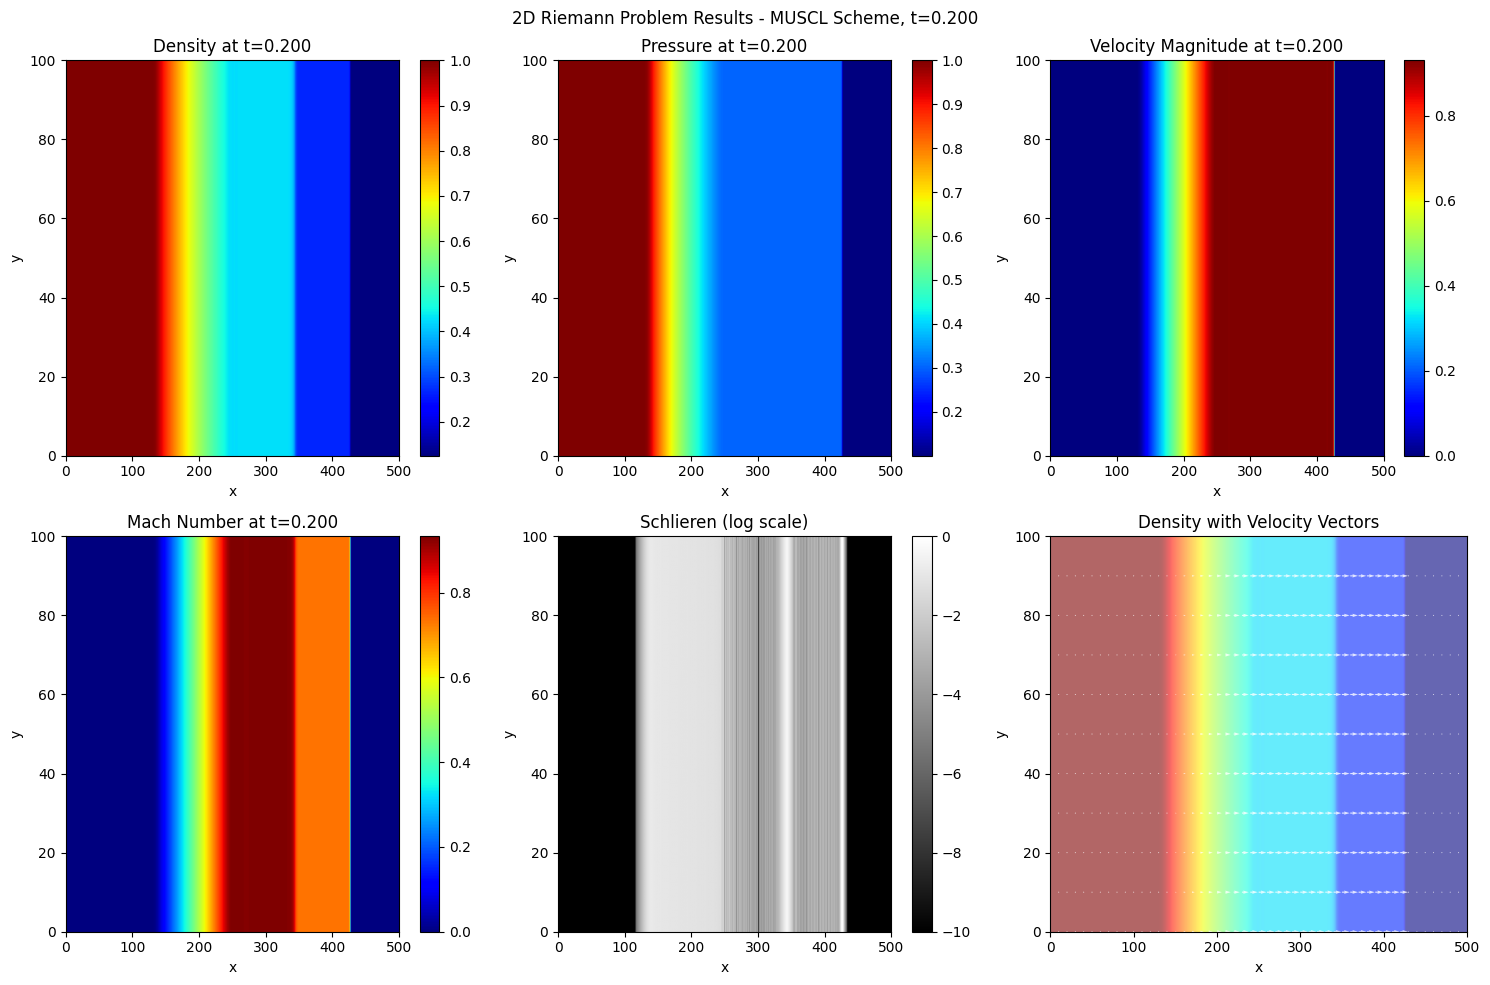

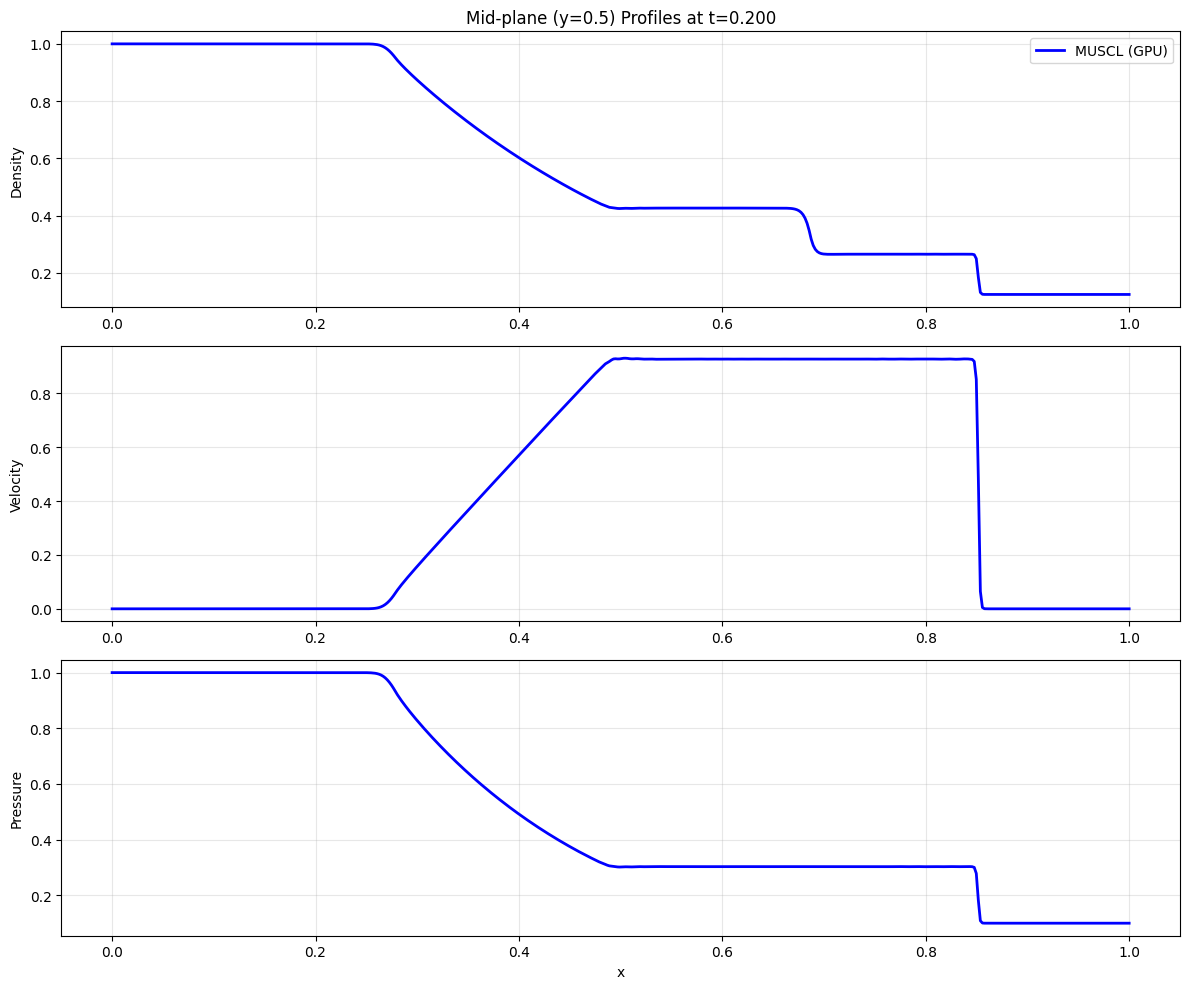


✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'

VALIDATION WITH EXACT SOD SOLUTION

L1 Errors at t=0.2:
  Density:  0.001549
  Velocity: 0.002406
  Pressure: 0.001050


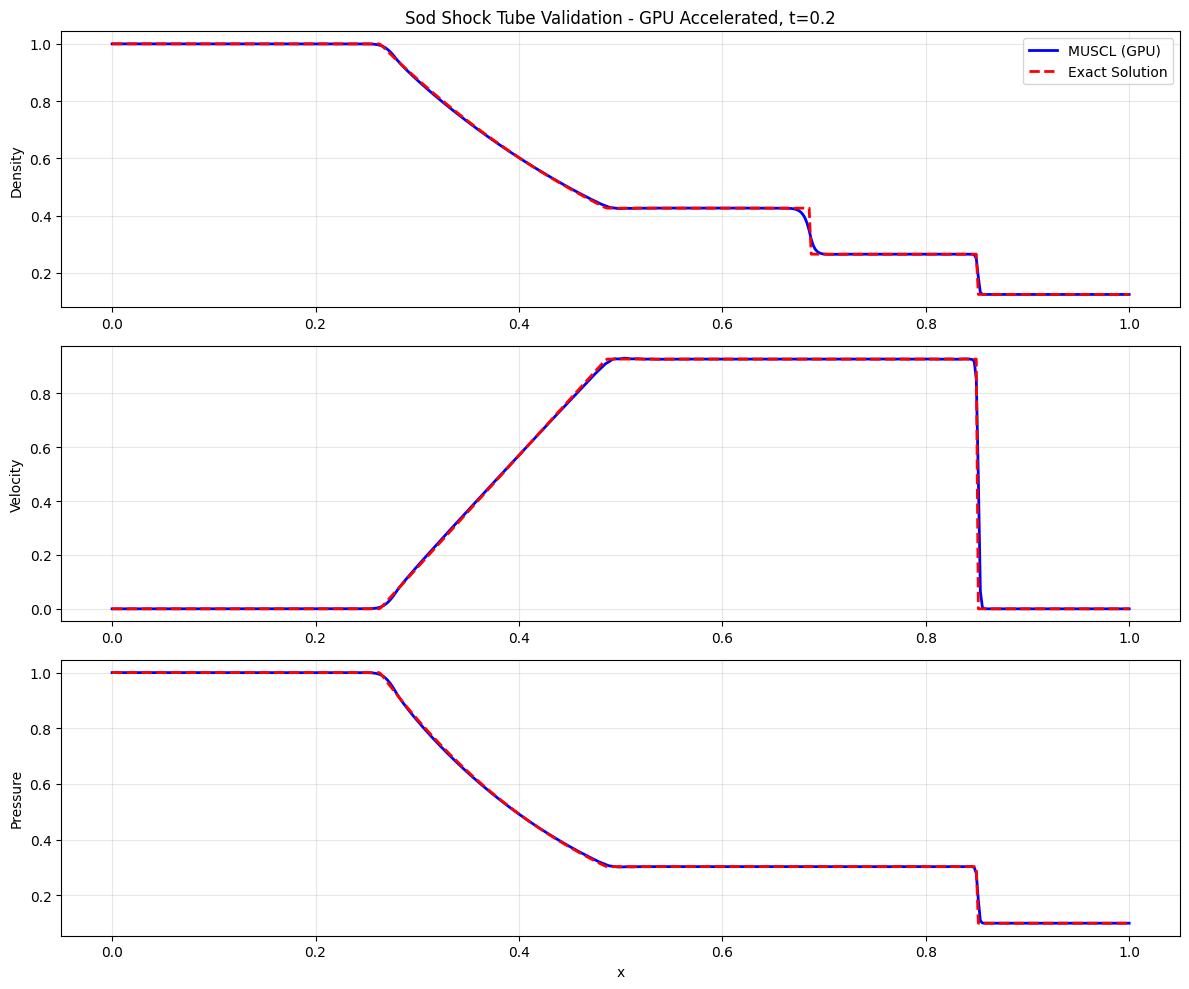


✓ Validation plot saved as 'validation.png'

All plots generated successfully!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import LogNorm
import warp as wp

# Initialize Warp
#wp.clear_kernel_cache()
wp.init()
# Select GPU if available, else fallback to CPU backend for Warp
device = "cuda" if wp.is_cuda_available() else "cpu"

# ============================================
# PARAMETERS
# ============================================
gamma = 1.4
NX, NY = 500, 100  # Your grid size
NG = 2  # Ghost cells

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.4
t_final = 0.2
EPS = 1e-8

# ========== SCHEME SELECTION ==========
NUMERICAL_SCHEME = 'muscl'  # or 'central'
TIME_STEPPING = 'euler'  # or 'rk2'

# ========== PERFORMANCE OPTIMIZATIONS ==========
SHOW_LIVE_PLOTS = False  # Keep False to avoid live plotting overhead
PRINT_EVERY_N_STEPS = 20  # Print progress

# ============================================
# INITIAL CONDITION (NumPy)
# ============================================

U_np = np.zeros((4, Nx, Ny), dtype=np.float32)

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U_np[0,i,j] = rho
        U_np[1,i,j] = rho*u
        U_np[2,i,j] = rho*v
        U_np[3,i,j] = p/(gamma-1.0) + 0.5*rho*(u*u+v*v)

# Convert to (Nx, Ny, 4) layout for Warp's vec4f
U_initial = np.transpose(U_np, (1, 2, 0)).copy()

# ============================================
# WARP KERNELS & FUNCTIONS
# ============================================

@wp.func
def cons_to_prim(U: wp.vec4f, gamma: float, EPS: float):
    rho = wp.max(U[0], EPS)
    u = U[1] / rho
    v = U[2] / rho
    E = U[3]
    p = wp.max((gamma - 1.0) * (E - 0.5 * rho * (u * u + v * v)), EPS)
    return rho, u, v, p

@wp.func
def prim_to_cons(rho: float, u: float, v: float, p: float, gamma: float):
    E = p / (gamma - 1.0) + 0.5 * rho * (u * u + v * v)
    return wp.vec4f(rho, rho * u, rho * v, E)

@wp.func
def minmod(a: float, b: float):
    if a * b <= 0.0:
        return 0.0
    if a > 0.0:
        return wp.min(a, b)
    else:
        return wp.max(a, b)

@wp.func
def reconstruct_state(U_m1: wp.vec4f, U_0: wp.vec4f, U_p1: wp.vec4f, U_p2: wp.vec4f, gamma: float, EPS: float):
    rho_m1, u_m1, v_m1, p_m1 = cons_to_prim(U_m1, gamma, EPS)
    rho_0,  u_0,  v_0,  p_0  = cons_to_prim(U_0, gamma, EPS)
    rho_p1, u_p1, v_p1, p_p1 = cons_to_prim(U_p1, gamma, EPS)
    rho_p2, u_p2, v_p2, p_p2 = cons_to_prim(U_p2, gamma, EPS)

    # Left state
    rho_L = rho_0 + 0.5 * minmod(rho_0 - rho_m1, rho_p1 - rho_0)
    u_L   = u_0   + 0.5 * minmod(u_0 - u_m1, u_p1 - u_0)
    v_L   = v_0   + 0.5 * minmod(v_0 - v_m1, v_p1 - v_0)
    p_L   = p_0   + 0.5 * minmod(p_0 - p_m1, p_p1 - p_0)

    # Right state
    rho_R = rho_p1 - 0.5 * minmod(rho_p1 - rho_0, rho_p2 - rho_p1)
    u_R   = u_p1   - 0.5 * minmod(u_p1 - u_0, u_p2 - u_p1)
    v_R   = v_p1   - 0.5 * minmod(v_p1 - v_0, v_p2 - v_p1)
    p_R   = p_p1   - 0.5 * minmod(p_p1 - p_0, p_p2 - p_p1)

    UL = prim_to_cons(rho_L, u_L, v_L, p_L, gamma)
    UR = prim_to_cons(rho_R, u_R, v_R, p_R, gamma)
    return UL, UR

@wp.func
def hllc_flux(UL: wp.vec4f, UR: wp.vec4f, gamma: float, EPS: float, dir_y: int):
    if dir_y == 1:
        UL = wp.vec4f(UL[0], UL[2], UL[1], UL[3])
        UR = wp.vec4f(UR[0], UR[2], UR[1], UR[3])

    rhoL = wp.max(UL[0], EPS)
    uL = UL[1] / rhoL
    vL = UL[2] / rhoL
    pL = wp.max((gamma - 1.0) * (UL[3] - 0.5 * rhoL * (uL * uL + vL * vL)), EPS)

    rhoR = wp.max(UR[0], EPS)
    uR = UR[1] / rhoR
    vR = UR[2] / rhoR
    pR = wp.max((gamma - 1.0) * (UR[3] - 0.5 * rhoR * (uR * uR + vR * vR)), EPS)

    cL = wp.sqrt(gamma * pL / rhoL)
    cR = wp.sqrt(gamma * pR / rhoR)

    sqrt_rhoL = wp.sqrt(rhoL)
    sqrt_rhoR = wp.sqrt(rhoR)
    u_avg = (sqrt_rhoL * uL + sqrt_rhoR * uR) / (sqrt_rhoL + sqrt_rhoR)
    c_avg = wp.sqrt(gamma * (pL + pR) / (rhoL + rhoR))

    SL = wp.min(uL - cL, u_avg - c_avg)
    SR = wp.max(uR + cR, u_avg + c_avg)

    FL = wp.vec4f(rhoL * uL, rhoL * uL * uL + pL, rhoL * uL * vL, uL * (UL[3] + pL))
    FR = wp.vec4f(rhoR * uR, rhoR * uR * uR + pR, rhoR * uR * vR, uR * (UR[3] + pR))

    flux = wp.vec4f(0.0, 0.0, 0.0, 0.0)
    if SL >= 0.0:
        flux = FL
    elif SR <= 0.0:
        flux = FR
    else:
        flux = (SR * FL - SL * FR + SL * SR * (UR - UL)) / (SR - SL)

    if dir_y == 1:
        flux = wp.vec4f(flux[0], flux[2], flux[1], flux[3])

    return flux

@wp.kernel
def apply_bc_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    src_i = i
    src_j = j

    if i < NG: src_i = NG
    elif i >= Nx - NG: src_i = Nx - NG - 1

    if j < NG: src_j = NG
    elif j >= Ny - NG: src_j = Ny - NG - 1

    if i != src_i or j != src_j:
        U[i, j] = U[src_i, src_j]

@wp.kernel
def compute_max_speed_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), max_speed_arr: wp.array(dtype=float), gamma: float, EPS: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rho, u, v, p = cons_to_prim(U[i, j], gamma, EPS)
        c = wp.sqrt(gamma * p / rho)
        speed = wp.abs(u) + wp.abs(v) + c
        wp.atomic_max(max_speed_arr, 0, speed)

@wp.kernel
def compute_fluxes_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), gamma: float, EPS: float, use_muscl: int, Nx: int, Ny: int):
    i, j = wp.tid()

    # X-flux at interface (i+1/2, j)
    if i >= 1 and i <= Nx - 3 and j >= 1 and j <= Ny - 2:
        if use_muscl == 1:
            UL_x, UR_x = reconstruct_state(U[i-1, j], U[i, j], U[i+1, j], U[i+2, j], gamma, EPS)
        else:
            UL_x = U[i, j]
            UR_x = U[i+1, j]
        Fx[i, j] = hllc_flux(UL_x, UR_x, gamma, EPS, 0)

    # Y-flux at interface (i, j+1/2)
    if i >= 1 and i <= Nx - 2 and j >= 1 and j <= Ny - 3:
        if use_muscl == 1:
            UL_y, UR_y = reconstruct_state(U[i, j-1], U[i, j], U[i, j+1], U[i, j+2], gamma, EPS)
        else:
            UL_y = U[i, j]
            UR_y = U[i, j+1]
        Fy[i, j] = hllc_flux(UL_y, UR_y, gamma, EPS, 1)

@wp.kernel
def compute_rhs_kernel(Fx: wp.array(dtype=wp.vec4f, ndim=2), Fy: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), dx: float, dy: float, NG: int, Nx: int, Ny: int):
    i, j = wp.tid()
    if i >= NG and i < Nx - NG and j >= NG and j < Ny - NG:
        rhs[i, j] = (Fx[i-1, j] - Fx[i, j]) / dx + (Fy[i, j-1] - Fy[i, j]) / dy

@wp.kernel
def euler_step_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step1_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), rhs: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U1[i, j] = U[i, j] + rhs[i, j] * dt

@wp.kernel
def rk2_step2_kernel(U: wp.array(dtype=wp.vec4f, ndim=2), U1: wp.array(dtype=wp.vec4f, ndim=2), rhs1: wp.array(dtype=wp.vec4f, ndim=2), U_new: wp.array(dtype=wp.vec4f, ndim=2), dt: float):
    i, j = wp.tid()
    U_new[i, j] = 0.5 * (U[i, j] + U1[i, j] + rhs1[i, j] * dt)

# ============================================
# UTILITY FUNCTIONS
# ============================================

def get_numpy_state(U_wp):
    # Retrieve from GPU and transpose back to (4, Nx, Ny)
    return U_wp.numpy().transpose((2, 0, 1))

def compute_mean_values_np(U):
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / rho
    v = U[2, NG:-NG, NG:-NG] / rho
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    return np.mean(rho), np.mean(np.sqrt(u*u + v*v)), np.mean(p)

def exact_sod(x, t, gamma=1.4):
    """Exact solution for Sod shock tube problem"""
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i
        if p > p_i:
            return (p - p_i) * np.sqrt(A / (p + B))
        else:
            return (2 * np.sqrt(gamma * p_i / rho) / (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    p = 0.5 * (pL + pR)
    for _ in range(50):
        fL, fR = f(p, rhoL, pL), f(p, rhoR, pR)
        func = fL + fR + uR - uL
        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR) / dp
        p -= func / df
        p = max(p, 1e-6)

    p_star, u_star = p, 0.5 * (uL + uR + f(p, rhoR, pR) - f(p, rhoL, pL))
    cL, cR = np.sqrt(gamma * pL / rhoL), np.sqrt(gamma * pR / rhoR)
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma * p_star / (rhoL * (p_star / pL)**(1/gamma)))
    SR = uR + cR * np.sqrt((gamma + 1)/(2*gamma) * (p_star/pR - 1) + 1)

    rho, u, p_out = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i in range(len(x)):
        xi = (x[i] - 0.5) / t
        if xi < SHL: rho[i], u[i], p_out[i] = rhoL, uL, pL
        elif xi <= STL:
            u_i = (2/(gamma+1)) * (cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)
            rho[i], u[i], p_out[i] = rhoL * (c_i/cL)**(2/(gamma-1)), u_i, pL * (c_i/cL)**(2*gamma/(gamma-1))
        elif xi < u_star: rho[i], u[i], p_out[i] = rhoL * (p_star/pL)**(1/gamma), u_star, p_star
        elif xi <= SR: rho[i], u[i], p_out[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) / ((gamma-1)/(gamma+1) * p_star/pR + 1)), u_star, p_star
        else: rho[i], u[i], p_out[i] = rhoR, uR, pR
    return rho, u, p_out

def plot_final_results(U, t_final, gamma, NG, NX, NY):
    """Create comprehensive final plots after simulation"""

    # Extract fields
    rho = U[0, NG:-NG, NG:-NG]
    u = U[1, NG:-NG, NG:-NG] / (rho + 1e-10)
    v = U[2, NG:-NG, NG:-NG] / (rho + 1e-10)
    p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u + v*v))
    p = np.maximum(p, 1e-6)  # Avoid negative pressure

    # Mach number
    c = np.sqrt(gamma * p / (rho + 1e-10))
    Mach = np.sqrt(u*u + v*v) / (c + 1e-10)

    # Schlieren (gradient of density)
    grad_x = np.gradient(rho, axis=0)
    grad_y = np.gradient(rho, axis=1)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    schlieren = np.log10(grad_mag / (np.max(grad_mag) + 1e-10) + 1e-10)

    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot 1: Density
    im1 = axes[0,0].imshow(rho.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,0].set_title(f'Density at t={t_final:.3f}')
    axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0,0])

    # Plot 2: Pressure
    im2 = axes[0,1].imshow(p.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,1].set_title(f'Pressure at t={t_final:.3f}')
    axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0,1])

    # Plot 3: Velocity magnitude
    vel_mag = np.sqrt(u**2 + v**2)
    im3 = axes[0,2].imshow(vel_mag.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[0,2].set_title(f'Velocity Magnitude at t={t_final:.3f}')
    axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('y')
    plt.colorbar(im3, ax=axes[0,2])

    # Plot 4: Mach Number
    im4 = axes[1,0].imshow(Mach.T, origin='lower', cmap='jet',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,0].set_title(f'Mach Number at t={t_final:.3f}')
    axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1,0])

    # Plot 5: Schlieren
    im5 = axes[1,1].imshow(schlieren.T, origin='lower', cmap='gray',
                           extent=[0, NX, 0, NY], aspect='auto')
    axes[1,1].set_title('Schlieren (log scale)')
    axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
    plt.colorbar(im5, ax=axes[1,1])

    # Plot 6: Streamlines or velocity vectors (simplified)
    # Downsample for clarity
    stride = 10
    X, Y = np.meshgrid(np.arange(0, NX, stride), np.arange(0, NY, stride))
    U_ds = u[::stride, ::stride]
    V_ds = v[::stride, ::stride]
    axes[1,2].imshow(rho.T, origin='lower', cmap='jet', alpha=0.6,
                     extent=[0, NX, 0, NY], aspect='auto')
    axes[1,2].quiver(X, Y, U_ds.T, V_ds.T, alpha=0.8, color='white', scale=50)
    axes[1,2].set_title('Density with Velocity Vectors')
    axes[1,2].set_xlabel('x'); axes[1,2].set_ylabel('y')

    plt.suptitle(f'2D Riemann Problem Results - {NUMERICAL_SCHEME.upper()} Scheme, t={t_final:.3f}')
    plt.tight_layout()
    plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Also create a line plot at mid-plane for comparison
    j_mid = NY // 2
    rho_mid = U[0, NG:-NG, j_mid]
    u_mid = U[1, NG:-NG, j_mid] / (rho_mid + 1e-10)
    p_mid = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_mid*u_mid**2)

    x = np.linspace(0, 1, NX)

    plt.figure(figsize=(12, 10))
    plt.subplot(3, 1, 1)
    plt.plot(x, rho_mid, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'Mid-plane (y=0.5) Profiles at t={t_final:.3f}')

    plt.subplot(3, 1, 2)
    plt.plot(x, u_mid, 'b-', linewidth=2)
    plt.ylabel('Velocity')
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(x, p_mid, 'b-', linewidth=2)
    plt.ylabel('Pressure')
    plt.xlabel('x')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('midplane_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Final plots saved as 'final_results.png' and 'midplane_profiles.png'")

# ============================================
# MAIN GPU SIMULATION LOOP
# ============================================

print(f"Grid: {NX}×{NY}")
print(f"Scheme: {NUMERICAL_SCHEME.upper()} (GPU - {device})")
print(f"Time stepping: {TIME_STEPPING.upper()}")
print("="*50)

# Allocate Warp Arrays
U_wp = wp.array(U_initial, dtype=wp.vec4f, device=device)
U_new_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
U1_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fx_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
Fy_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
rhs_wp = wp.zeros((Nx, Ny), dtype=wp.vec4f, device=device)
max_speed_arr = wp.zeros(1, dtype=float, device=device)

use_muscl_flag = 1 if NUMERICAL_SCHEME == 'muscl' else 0

wp.synchronize()
start_time = time.time()
t = 0.0
step = 0

estimated_steps = int(t_final / (CFL * min(dx, dy) / 0.5))
print(f"Estimated total steps: ~{estimated_steps}")
print("="*50)

# Run simulation without live plotting
while t < t_final:
    wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U_wp, NG, Nx, Ny], device=device)

    # Calculate dt dynamically via atomic reduction
    max_speed_arr.fill_(0.0)
    wp.launch(compute_max_speed_kernel, dim=(Nx, Ny), inputs=[U_wp, max_speed_arr, gamma, EPS, NG, Nx, Ny], device=device)
    max_speed = max_speed_arr.numpy()[0]
    dt = CFL * min(dx, dy) / max_speed
    if t + dt > t_final: dt = t_final - t

    if TIME_STEPPING == 'euler':
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(euler_step_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    elif TIME_STEPPING == 'rk2':
        # RK2 Step 1
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step1_kernel, dim=(Nx, Ny), inputs=[U_wp, rhs_wp, U1_wp, float(dt)], device=device)
        wp.launch(apply_bc_kernel, dim=(Nx, Ny), inputs=[U1_wp, NG, Nx, Ny], device=device)

        # RK2 Step 2 (SSPRK2)
        wp.launch(compute_fluxes_kernel, dim=(Nx, Ny), inputs=[U1_wp, Fx_wp, Fy_wp, gamma, EPS, use_muscl_flag, Nx, Ny], device=device)
        wp.launch(compute_rhs_kernel, dim=(Nx, Ny), inputs=[Fx_wp, Fy_wp, rhs_wp, dx, dy, NG, Nx, Ny], device=device)
        wp.launch(rk2_step2_kernel, dim=(Nx, Ny), inputs=[U_wp, U1_wp, rhs_wp, U_new_wp, float(dt)], device=device)
        wp.copy(U_wp, U_new_wp)

    t += dt
    step += 1

    if step % PRINT_EVERY_N_STEPS == 0:
        elapsed = time.time() - start_time
        steps_per_sec = step / elapsed if elapsed > 0 else 0
        U_np = get_numpy_state(U_wp)
        rho_mean, u_mean, p_mean = compute_mean_values_np(U_np)
        print(f"Step {step:6d} | t={t:.5f}/{t_final} | dt={dt:.5f} | "
              f"ρ={rho_mean:.4f} | p={p_mean:.4f} | speed={steps_per_sec:.1f} steps/s")

wp.synchronize()
end_time = time.time()
print("="*50)
print(f"Simulation completed in {end_time - start_time:.2f} seconds")
print(f"Total steps: {step}")
print(f"Average speed: {step/(end_time-start_time):.1f} steps/second")

# ============================================
# POST-PROCESSING: CREATE FINAL PLOTS
# ============================================

print("\n" + "="*50)
print("CREATING FINAL PLOTS")
print("="*50)

# Get final state
U_final = get_numpy_state(U_wp)

# Create comprehensive final plots
plot_final_results(U_final, t_final, gamma, NG, NX, NY)

# ============================================
# VALIDATION WITH EXACT SOLUTION (CPU)
# ============================================

print("\n" + "="*50)
print("VALIDATION WITH EXACT SOD SOLUTION")
print("="*50)

j_mid = NY // 2
rho_num = U_final[0, NG:-NG, j_mid]
u_num = U_final[1, NG:-NG, j_mid] / (rho_num + 1e-10)
p_num = (gamma-1)*(U_final[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)
rho_ex, u_ex, p_ex = exact_sod(x, t_final, gamma)

print(f"\nL1 Errors at t={t_final}:")
print(f"  Density:  {np.mean(np.abs(rho_num - rho_ex)):.6f}")
print(f"  Velocity: {np.mean(np.abs(u_num - u_ex)):.6f}")
print(f"  Pressure: {np.mean(np.abs(p_num - p_ex)):.6f}")

# Create validation plot
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(x, rho_num, 'b-', linewidth=2, label=f'{NUMERICAL_SCHEME.upper()} (GPU)')
plt.plot(x, rho_ex, 'r--', linewidth=2, label='Exact Solution')
plt.ylabel('Density'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title(f'Sod Shock Tube Validation - GPU Accelerated, t={t_final}')

plt.subplot(3, 1, 2)
plt.plot(x, u_num, 'b-', linewidth=2)
plt.plot(x, u_ex, 'r--', linewidth=2)
plt.ylabel('Velocity'); plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(x, p_num, 'b-', linewidth=2)
plt.plot(x, p_ex, 'r--', linewidth=2)
plt.ylabel('Pressure'); plt.xlabel('x'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Validation plot saved as 'validation.png'")
print("\nAll plots generated successfully!")